# HW1 Part A — Data Loading, Preprocessing & EDA
## CS 455/555 — Song2Vec / 30Music Dataset

In [1]:
import json
import random
import re
import statistics
import urllib.parse
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

DATA_DIR = Path("Data-20260316T070715Z-1-001/Data")
TRACKS_FILE   = DATA_DIR / "tracks.idomaar"
PLAYLIST_FILE = DATA_DIR / "playlist.idomaar"

RANDOM_SEED  = 42
TRAIN_RATIO  = 0.80
MIN_TRACKS   = 2
MIN_COUNT    = 5

## A.1 — Data Loading & Preprocessing

### Step 1 — Build track ID → identifier lookup from tracks.idomaar

In [2]:
def normalize(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def get_track_name(raw_name: str):
    # format is Artist/_/Title, url-encoded
    decoded = urllib.parse.unquote_plus(raw_name)
    if "/_/" not in decoded:
        return None
    artist, title = decoded.split("/_/", 1)
    return normalize(artist), normalize(title)


print("Building track lookup …")
track_lookup: dict[int, str] = {}   # track_id → "artist__title"
skipped = 0

with open(TRACKS_FILE, encoding="utf-8", errors="replace") as fh:
    for line in fh:
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 4:
            skipped += 1
            continue
        try:
            meta = json.loads(parts[3])
        except json.JSONDecodeError:
            skipped += 1
            continue

        raw_name = meta.get("name", "")
        parsed = get_track_name(raw_name)
        if parsed is None:
            skipped += 1
            continue

        track_id = int(parts[1])
        artist, title = parsed
        track_lookup[track_id] = f"{artist}__{title}"

print(f"  Loaded {len(track_lookup):,} tracks  (skipped {skipped:,} malformed lines)")

sample_ids = list(track_lookup)[:5]
for tid in sample_ids:
    print(f"  {tid:>8}  →  {track_lookup[tid]}")

Building track lookup …
  Loaded 4,519,105 tracks  (skipped 0 malformed lines)
         0  →  000003 music instructor__dj's rock da house â≈æ≈ê01 - dj max-pulemet vs. bomfunk mc's - electro breakdance party 1 [2000] = cd oneâ≈æ≈ê
         1  →  00-01__текст
         2  →  0005. overkill__overkill
         3  →  000c tony dize__ruleta rusa
         4  →  000 oscarcito__tumbay‚ (lyrics)


### Step 2 — Parse playlists from playlist.idomaar

In [3]:
print("Parsing playlists …")
all_playlists: list[list[str]] = []
raw_total       = 0
dropped_short   = 0
missing_tracks  = 0

with open(PLAYLIST_FILE, encoding="utf-8", errors="replace") as fh:
    for line in fh:
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 5:
            continue
        try:
            objects = json.loads(parts[4])
        except json.JSONDecodeError:
            continue

        raw_total += 1
        track_ids = [
            obj["id"]
            for obj in objects.get("objects", [])
            if isinstance(obj, dict) and obj.get("type") == "track"
        ]

        if len(track_ids) < MIN_TRACKS:
            dropped_short += 1
            continue

        orig_len = len(track_ids)
        identifiers = [track_lookup[tid] for tid in track_ids if tid in track_lookup]
        missing_tracks += orig_len - len(identifiers)

        if len(identifiers) < MIN_TRACKS:
            dropped_short += 1
            continue

        all_playlists.append(identifiers)

print(f"  Raw playlists parsed : {raw_total:,}")
print(f"  Dropped (too short)  : {dropped_short:,}")
print(f"  Track refs not found : {missing_tracks:,}")
print(f"  Usable playlists     : {len(all_playlists):,}")

Parsing playlists …
  Raw playlists parsed : 57,561
  Dropped (too short)  : 10,431
  Track refs not found : 0
  Usable playlists     : 47,130


### Step 3 — Train / Test split (80 / 20, playlist-level)

In [4]:
random.seed(RANDOM_SEED)
shuffled = all_playlists[:]
random.shuffle(shuffled)

split_idx = int(len(shuffled) * TRAIN_RATIO)
train_playlists = shuffled[:split_idx]
test_playlists  = shuffled[split_idx:]

print(f"Train playlists : {len(train_playlists):,}")
print(f"Test  playlists : {len(test_playlists):,}")
assert len(train_playlists) + len(test_playlists) == len(all_playlists), "Split sanity check failed!"
print("train + test == total")

Train playlists : 37,704
Test  playlists : 9,426
train + test == total


## A.2 — Exploratory Data Analysis

In [5]:
# Build track frequency counts over training set (used by multiple EDA cells)
track_counts = Counter(
    track for playlist in train_playlists for track in playlist
)
print(f"Unique tracks in training set: {len(track_counts):,}")

Unique tracks in training set: 392,918


### Plot 1 — Playlist Length Distribution

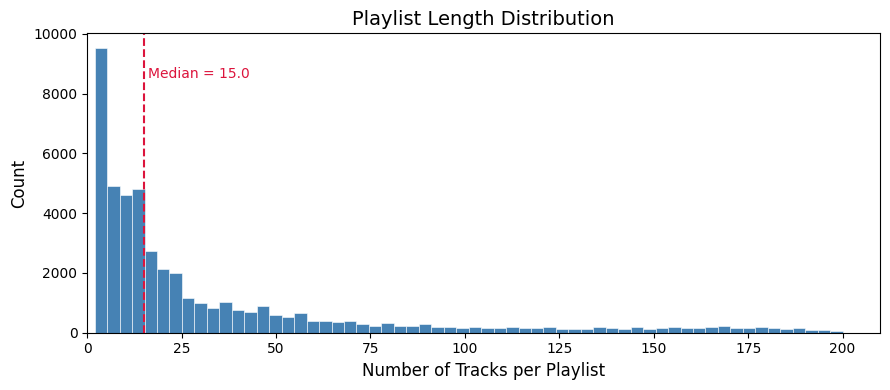

  Min length : 2
  Max length : 200
  Mean length: 34.0
  Median     : 15.0

  Short  (≤10 tracks) : 17,636  (37.4%)
  Medium (11–30)      : 14,956  (31.7%)
  Long   (>30 tracks) : 14,538  (30.8%)

  → Median ≈ 15.0 tracks → window=3 is reasonable


In [6]:
lengths = [len(p) for p in all_playlists]
median_len = statistics.median(lengths)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lengths, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(median_len, color="crimson", linestyle="--", linewidth=1.5)
ax.text(median_len + 1, ax.get_ylim()[1] * 0.85,
        f"Median = {median_len}", color="crimson", fontsize=10)
ax.set_xlabel("Number of Tracks per Playlist", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Playlist Length Distribution", fontsize=14)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig("playlist_length_distribution.png", dpi=150)
plt.show()

print(f"  Min length : {min(lengths)}")
print(f"  Max length : {max(lengths)}")
print(f"  Mean length: {sum(lengths)/len(lengths):.1f}")
print(f"  Median     : {median_len}")

n_short, n_medium, n_long = 0, 0, 0
for l in lengths:
    if l <= 10:
        n_short += 1
    elif l <= 30:
        n_medium += 1
    else:
        n_long += 1
n_total  = len(lengths)
print(f"\n  Short  (≤10 tracks) : {n_short:>6,}  ({100*n_short/n_total:.1f}%)")
print(f"  Medium (11–30)      : {n_medium:>6,}  ({100*n_medium/n_total:.1f}%)")
print(f"  Long   (>30 tracks) : {n_long:>6,}  ({100*n_long/n_total:.1f}%)")
print(f"\n  → Median ≈ {median_len} tracks → window=3 is reasonable")

### Plot 2 — Track Frequency Distribution (Log-Log, Zipf / Power-law)

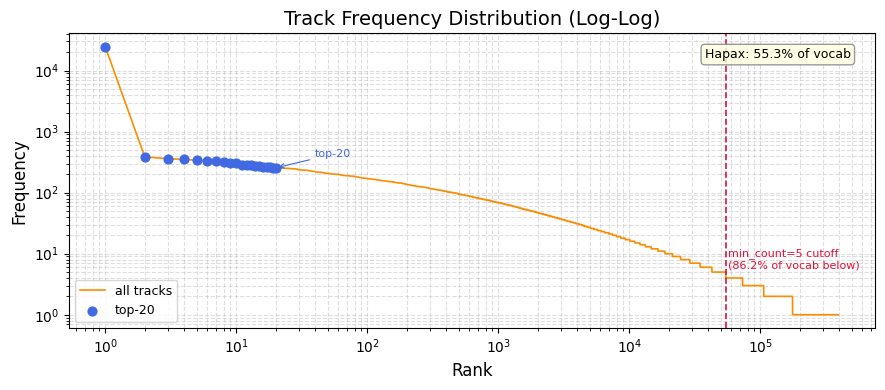

  Cutoff rank (freq < 5): 54,271  (86.2% of vocab below cutoff)


In [7]:
freqs = sorted(track_counts.values(), reverse=True)
ranks = list(range(1, len(freqs) + 1))

cutoff_rank = next((r for r, f in zip(ranks, freqs) if f < MIN_COUNT), len(freqs))
below_pct   = 100 * (len(freqs) - cutoff_rank) / len(freqs)

hapax_pct = 100 * sum(1 for f in freqs if f == 1) / len(freqs)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(ranks, freqs, linewidth=1.2, color="darkorange", label="all tracks")

top20_ranks = ranks[:20]
top20_freqs = freqs[:20]
ax.scatter(top20_ranks, top20_freqs, color="royalblue", zorder=5,
           s=40, label="top-20")
ax.annotate("top-20", xy=(20, top20_freqs[-1]),
            xytext=(40, top20_freqs[-1] * 1.5),
            fontsize=8, color="royalblue",
            arrowprops=dict(arrowstyle="->", color="royalblue", lw=0.8))

ax.axvline(cutoff_rank, color="crimson", linestyle="--", linewidth=1.2)
ax.text(cutoff_rank * 1.05, freqs[cutoff_rank // 2],
        f"min_count=5 cutoff\n({below_pct:.1f}% of vocab below)",
        color="crimson", fontsize=8, va="center")

ax.text(0.97, 0.95, f"Hapax: {hapax_pct:.1f}% of vocab",
        transform=ax.transAxes, fontsize=9, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.8))

ax.set_xlabel("Rank", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Track Frequency Distribution (Log-Log)", fontsize=14)
ax.grid(True, which="both", linestyle="--", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("track_frequency_loglog.png", dpi=150)
plt.show()

print(f"  Cutoff rank (freq < {MIN_COUNT}): {cutoff_rank:,}  ({below_pct:.1f}% of vocab below cutoff)")

### Plot 3 — Top-K Analysis: Top 20 Tracks & Top 20 Artists

In [8]:
top20_tracks = track_counts.most_common(20)
print("Top 20 tracks (artist__title  →  count)")
print("-" * 60)
for rank, (track, cnt) in enumerate(top20_tracks, 1):
    print(f"  {rank:>2}. {track:<45}  {cnt:>6,}")

artist_counts: Counter = Counter()
for track, cnt in track_counts.items():
    artist = track.split("__")[0]   # "artist__title" → "artist"
    artist_counts[artist] += cnt

top20_artists = artist_counts.most_common(20)
print("\nTop 20 artists  →  total appearances")
print("-" * 50)
for rank, (artist, cnt) in enumerate(top20_artists, 1):
    print(f"  {rank:>2}. {artist:<35}  {cnt:>6,}")

Top 20 tracks (artist__title  →  count)
------------------------------------------------------------
   1. zz top__she loves my automobile                24,616
   2. massive attack__teardrop                          386
   3. radiohead__karma police                           360
   4. joy division__love will tear us apart             350
   5. nirvana__smells like teen spirit                  340
   6. radiohead__creep                                  332
   7. mgmt__kids                                        328
   8. the killers__mr. brightside                       314
   9. the rolling stones__paint it black                311
  10. oasis__wonderwall                                 306
  11. depeche mode__enjoy the silence                   289
  12. muse__starlight                                   280
  13. mgmt__time to pretend                             279
  14. coldplay__viva la vida                            271
  15. franz ferdinand__take me out                      271

### Plot 4 — Top-20 Artists Bar Chart

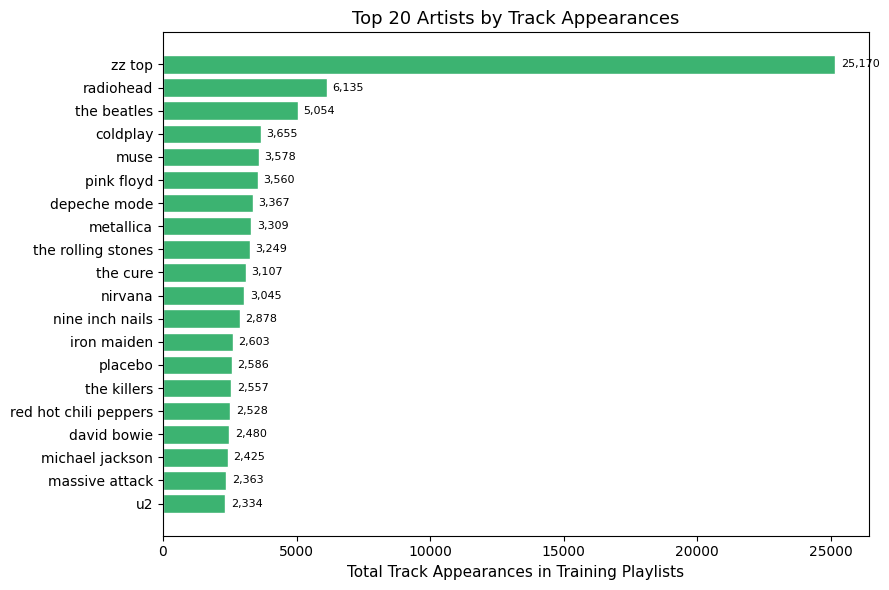

In [9]:
artists_names  = [a for a, _ in top20_artists][::-1]
artists_counts = [c for _, c in top20_artists][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(artists_names, artists_counts, color="mediumseagreen", edgecolor="white")
ax.set_xlabel("Total Track Appearances in Training Playlists", fontsize=11)
ax.set_title("Top 20 Artists by Track Appearances", fontsize=13)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=8)
plt.tight_layout()
plt.savefig("top20_artists.png", dpi=150)
plt.show()

### Vocabulary Statistics

In [10]:
total_unique   = len(track_counts)
tot_occ = sum(track_counts.values())
hapax          = sum(1 for c in track_counts.values() if c == 1)

top1k = sum(c for _, c in track_counts.most_common(1_000))
top10k = sum(c for _, c in track_counts.most_common(10_000))

print("Vocabulary Statistics")
print("=" * 45)
print(f"  Total unique tracks        : {total_unique:>10,}")
print(f"  Total track occurrences    : {tot_occ:>10,}")
print(f"  Hapax legomena (freq == 1) : {hapax:>10,}  ({100*hapax/total_unique:.1f}% of vocab)")
print()
print(f"  Coverage by top-1,000  tracks : {100*top1k/tot_occ:.2f}%")
print(f"  Coverage by top-10,000 tracks : {100*top10k/tot_occ:.2f}%")

Vocabulary Statistics
  Total unique tracks        :    392,918
  Total track occurrences    :  1,278,504
  Hapax legomena (freq == 1) :    217,356  (55.3% of vocab)

  Coverage by top-1,000  tracks : 10.58%
  Coverage by top-10,000 tracks : 31.22%


### Plot 5 — Popularity Bucket Analysis

Bucket          #Unique   %Vocab   #TestOcc   %TestOcc
------------------------------------------------------
  >1000               1     0.0%      6,420       2.0%
  100–1000          453     0.1%     16,322       5.0%
  10–100         20,829     5.3%    106,672      33.0%
  5–10           32,987     8.4%     44,832      13.9%
  <5            338,648    86.2%    148,998      46.1%


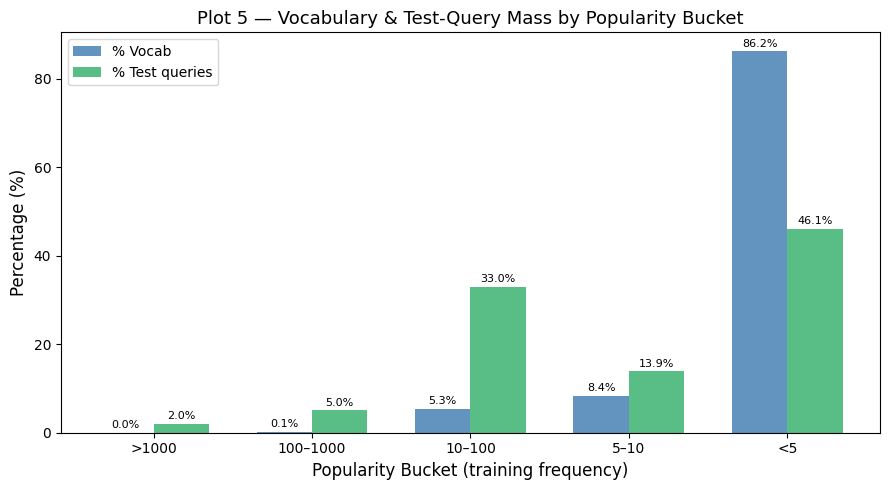

In [11]:
# Build test track counts
test_track_counts: Counter = Counter(
    track for playlist in test_playlists for track in playlist
)
test_total_occ = sum(test_track_counts.values())

BUCKET_LABELS  = [">1000", "100–1000", "10–100", "5–10", "<5"]
BUCKET_RANGES  = [(1001, None), (100, 1001), (10, 100), (5, 10), (0, 5)]

def get_bucket(count):
    for i, (lo, hi) in enumerate(BUCKET_RANGES):
        if hi is None:
            if count >= lo:
                return i
        else:
            if lo <= count < hi:
                return i
    return len(BUCKET_RANGES) - 1

bucket_vocab  = [0] * len(BUCKET_LABELS)  # #unique tracks
bucket_test   = [0] * len(BUCKET_LABELS)  # #test occurrences
for track, cnt in track_counts.items():
    b = get_bucket(cnt)
    bucket_vocab[b] += 1
for track, cnt in test_track_counts.items():
    train_cnt = track_counts.get(track, 0)
    b = get_bucket(train_cnt)
    bucket_test[b] += cnt

vocab_total = len(track_counts)
print(f"{'Bucket':<12} {'#Unique':>10} {'%Vocab':>8} {'#TestOcc':>10} {'%TestOcc':>10}")
print("-" * 54)
for label, v, t in zip(BUCKET_LABELS, bucket_vocab, bucket_test):
    vp = 100 * v / vocab_total if vocab_total else 0
    tp = 100 * t / test_total_occ if test_total_occ else 0
    print(f"  {label:<10} {v:>10,} {vp:>7.1f}% {t:>10,} {tp:>9.1f}%")

# Grouped bar chart
x      = np.arange(len(BUCKET_LABELS))
width  = 0.35
vpcts  = [100 * v / vocab_total for v in bucket_vocab]
tpcts  = [100 * t / test_total_occ for t in bucket_test]

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, vpcts, width, label="% Vocab",       color="steelblue",     alpha=0.85)
bars2 = ax.bar(x + width/2, tpcts, width, label="% Test queries", color="mediumseagreen", alpha=0.85)
ax.bar_label(bars1, fmt="%.1f%%", fontsize=8, padding=2)
ax.bar_label(bars2, fmt="%.1f%%", fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(BUCKET_LABELS)
ax.set_xlabel("Popularity Bucket (training frequency)", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("Plot 5 — Vocabulary & Test-Query Mass by Popularity Bucket", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("popularity_buckets.png", dpi=150)
plt.show()

### Plot 6 — Co-occurrence Heatmap of Top-30 Tracks

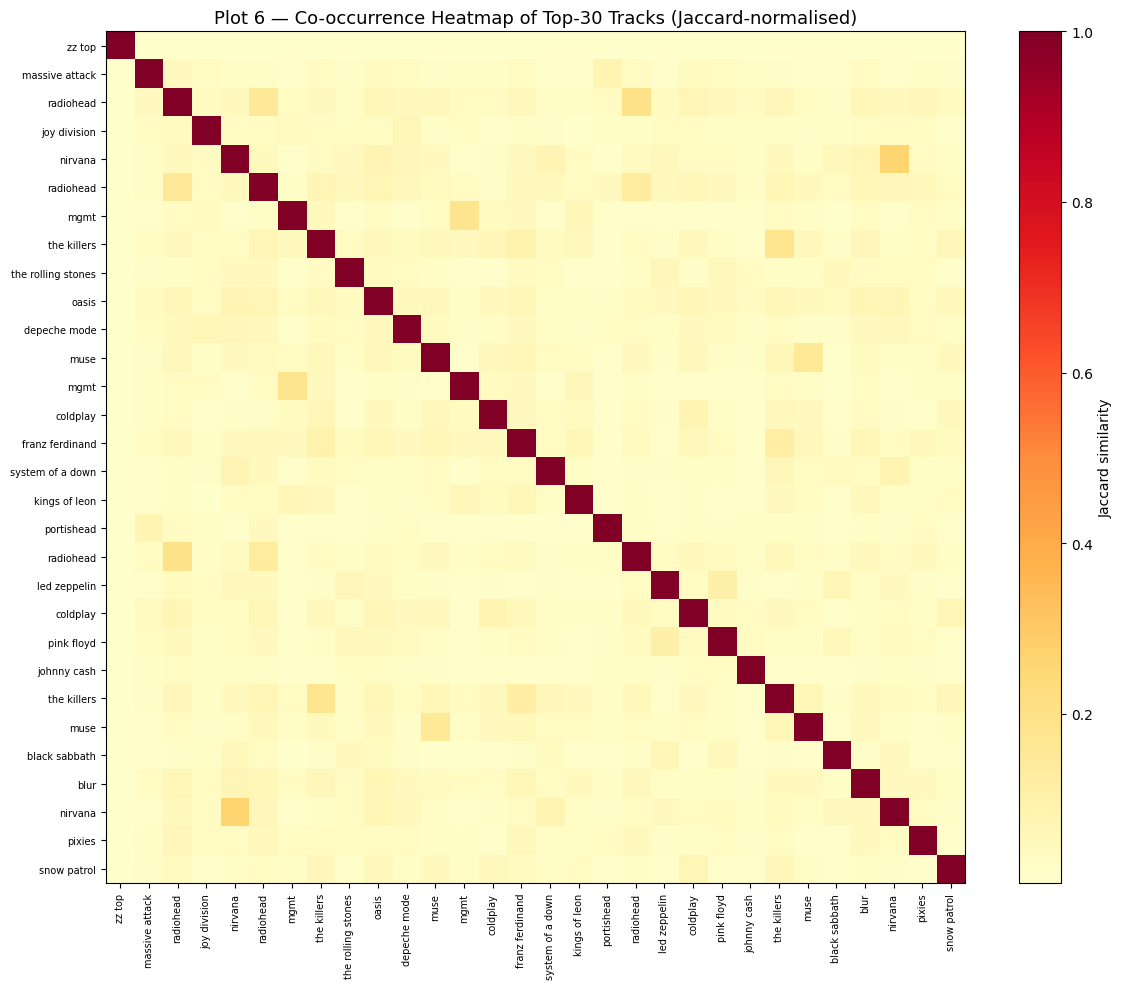

  Heatmap saved → cooccurrence_heatmap.png


In [12]:
# co-occurrence of top 30 tracks
top30_tracks = [t for t, _ in track_counts.most_common(30)]
track_to_idx = {t: i for i, t in enumerate(top30_tracks)}
n = len(top30_tracks)

cooc = np.zeros((n, n), dtype=np.float64)

for playlist in train_playlists:
    present = [track_to_idx[t] for t in playlist if t in track_to_idx]
    for ii in range(len(present)):
        for jj in range(len(present)):
            cooc[present[ii], present[jj]] += 1

diag = np.diag(cooc).copy()
cooc_norm = np.zeros_like(cooc)
for ii in range(n):
    for jj in range(n):
        denom = diag[ii] + diag[jj] - cooc[ii, jj]
        cooc_norm[ii, jj] = cooc[ii, jj] / denom if denom > 0 else 0.0

short_labels = [t.split("__")[0][:18] for t in top30_tracks]

fig, ax = plt.subplots(figsize=(12, 10))
if HAS_SEABORN:
    sns.heatmap(cooc_norm, ax=ax, cmap="YlOrRd",
                xticklabels=short_labels, yticklabels=short_labels,
                linewidths=0.3, linecolor="lightgray")
else:
    im = ax.imshow(cooc_norm, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(n))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
    ax.set_yticks(range(n))
    ax.set_yticklabels(short_labels, fontsize=7)
    plt.colorbar(im, ax=ax, label="Jaccard similarity")

ax.set_title("Plot 6 — Co-occurrence Heatmap of Top-30 Tracks (Jaccard-normalised)", fontsize=13)
plt.tight_layout()
plt.savefig("cooccurrence_heatmap.png", dpi=150)
plt.show()
print("  Heatmap saved → cooccurrence_heatmap.png")

### Plot 7 — Playlist-level Track Popularity Homogeneity

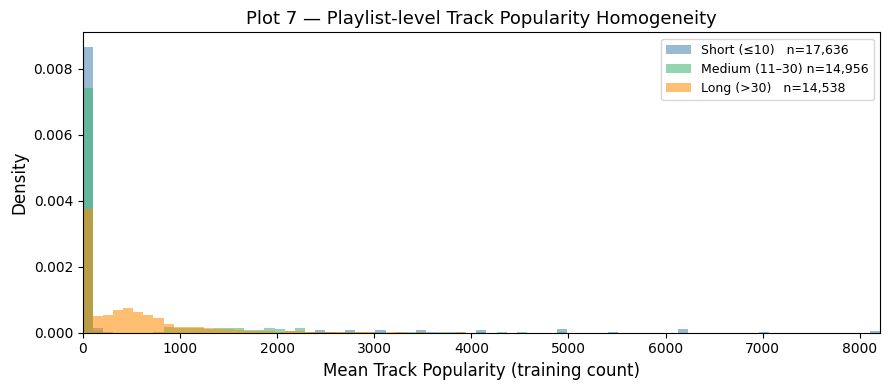

  Pearson r(length, mean_popularity) = -0.0268
  (Near 0 → popularity homogeneity is independent of playlist length)
  Overall mean-popularity median: 29.11


In [13]:
mean_pops = []
for playlist in all_playlists:
    if playlist:
        vals = [track_counts.get(t, 0) for t in playlist]
        mean_pops.append(sum(vals) / len(vals))

short_pops  = [mp for playlist, mp in zip(all_playlists, mean_pops) if len(playlist) <= 10]
medium_pops = [mp for playlist, mp in zip(all_playlists, mean_pops) if 11 <= len(playlist) <= 30]
long_pops   = [mp for playlist, mp in zip(all_playlists, mean_pops) if len(playlist) > 30]

fig, ax = plt.subplots(figsize=(9, 4))

bins = np.linspace(0, min(np.percentile(mean_pops, 99), max(mean_pops)), 80)

ax.hist(short_pops,  bins=bins, alpha=0.55, color="steelblue",    label=f"Short (≤10)   n={len(short_pops):,}",  density=True)
ax.hist(medium_pops, bins=bins, alpha=0.55, color="mediumseagreen",label=f"Medium (11–30) n={len(medium_pops):,}", density=True)
ax.hist(long_pops,   bins=bins, alpha=0.55, color="darkorange",   label=f"Long (>30)   n={len(long_pops):,}",   density=True)

ax.set_xlabel("Mean Track Popularity (training count)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Plot 7 — Playlist-level Track Popularity Homogeneity", fontsize=13)
ax.legend(fontsize=9)
ax.set_xlim(left=0, right=bins[-1])
plt.tight_layout()
plt.savefig("popularity_homogeneity.png", dpi=150)
plt.show()

# Pearson correlation between playlist length and mean popularity
lens = np.array([len(p) for p in all_playlists])
pop_arr = np.array(mean_pops)
corr = np.corrcoef(lens, pop_arr)[0, 1]
print(f"  Pearson r(length, mean_popularity) = {corr:.4f}")
print("  (Near 0 → popularity homogeneity is independent of playlist length)")
print(f"  Overall mean-popularity median: {statistics.median(mean_pops):.2f}")

In [14]:
import pickle
from pathlib import Path

PART_A_CACHE = Path("part_a_cache.pkl")
with open(PART_A_CACHE, "wb") as f:
    pickle.dump(dict(
        train_playlists=train_playlists,
        test_playlists=test_playlists,
        track_counts=track_counts,
        MIN_TRACKS=MIN_TRACKS,
        MIN_COUNT=MIN_COUNT,
        RANDOM_SEED=RANDOM_SEED,
    ), f)
print(f"Part A data saved → {PART_A_CACHE}  ({PART_A_CACHE.stat().st_size/1e6:.1f} MB)")

Part A data saved → part_a_cache.pkl  (23.8 MB)


## Part B — Song2Vec Model Training
### B.0 — Setup: Load Cache & Outlier Removal

In [15]:
import pickle
import random
import numpy as np

with open("part_a_cache.pkl", "rb") as f:
    cache = pickle.load(f)

train_playlists = cache["train_playlists"]
test_playlists  = cache["test_playlists"]
track_counts    = cache["track_counts"]
MIN_TRACKS      = cache["MIN_TRACKS"]
MIN_COUNT       = cache["MIN_COUNT"]
RANDOM_SEED     = cache["RANDOM_SEED"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

MAX_FREQ = 10_000
outlier_tracks = {t for t, c in track_counts.items() if c > MAX_FREQ}
print(f"Outlier tracks found (freq > {MAX_FREQ}): {len(outlier_tracks)}")

def remove_outliers(playlists, outliers, min_tracks):
    cleaned = []
    for pl in playlists:
        filtered = [t for t in pl if t not in outliers]
        if len(filtered) >= min_tracks:
            cleaned.append(filtered)
    return cleaned

train_playlists_clean = remove_outliers(train_playlists, outlier_tracks, MIN_TRACKS)
test_playlists_clean  = remove_outliers(test_playlists,  outlier_tracks, MIN_TRACKS)

print(f"Train playlists after cleaning : {len(train_playlists_clean):,}")
print(f"Test  playlists after cleaning : {len(test_playlists_clean):,}")

sentences = train_playlists_clean   # alias for Word2Vec training
print(f"Training sentences             : {len(sentences):,}")


Outlier tracks found (freq > 10000): 1
Train playlists after cleaning : 37,521
Test  playlists after cleaning : 9,387
Training sentences             : 37,521


## Part B.1 — Baseline Model

In [16]:
import pickle
import random
import time
import numpy as np
from gensim.models import Word2Vec

with open("part_a_cache.pkl", "rb") as f:
    cache = pickle.load(f)

train_playlists = cache["train_playlists"]
test_playlists  = cache["test_playlists"]
track_counts    = cache["track_counts"]
MIN_TRACKS      = cache["MIN_TRACKS"]
MIN_COUNT       = cache["MIN_COUNT"]
RANDOM_SEED     = cache["RANDOM_SEED"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

MAX_FREQ = 10_000
outlier_tracks = {t for t, c in track_counts.items() if c > MAX_FREQ}

def remove_outliers(playlists, outliers, min_tracks):
    cleaned = []
    for pl in playlists:
        filtered = [t for t in pl if t not in outliers]
        if len(filtered) >= min_tracks:
            cleaned.append(filtered)
    return cleaned

train_playlists_clean = remove_outliers(train_playlists, outlier_tracks, MIN_TRACKS)
test_playlists_clean  = remove_outliers(test_playlists,  outlier_tracks, MIN_TRACKS)
sentences = train_playlists_clean

print("Training baseline Song2Vec model …")
t0 = time.perf_counter()

model = Word2Vec(
    sentences=sentences,
    sg=1,
    window=5,
    negative=5,
    ns_exponent=0.75,
    min_count=5,
    vector_size=100,
    epochs=5,
    workers=4,
    sample=1e-3,
    seed=RANDOM_SEED,
)

train_time = time.perf_counter() - t0

model.save("song2vec_baseline.model")

print(f"Training time  : {train_time:.2f} s")
print(f"Vocabulary size: {len(model.wv):,}")
print("Model saved → song2vec_baseline.model")


Training baseline Song2Vec model …
Training time  : 6.22 s
Vocabulary size: 54,264
Model saved → song2vec_baseline.model


## Part B.2 — Hyperparameter Sweep

In [17]:
def evaluate_paper_approach(model, playlists, K=10):
    # Use second-to-last song as query, last as target
    vocab    = model.wv.key_to_index
    hr_sum   = 0.0
    ndcg_sum = 0.0
    n        = 0
    for pl in playlists:
        if len(pl) < 2:
            continue
        query  = pl[-2]
        target = pl[-1]
        if target not in vocab or query not in vocab:
            n += 1   # count as miss
            continue
        # Retrieve topn=K+20, then filter out the query song
        candidates = model.wv.most_similar(query, topn=K + 20)
        filtered   = [song for song, _ in candidates if song != query][:K]
        if target in filtered:
            hr_sum += 1.0
            rank    = filtered.index(target) + 1   # 1-indexed
            ndcg_sum += 1.0 / math.log2(rank + 1)
        n += 1
    if n == 0:
        return dict(hr=0.0, ndcg=0.0, n_evaluated=0)
    return dict(hr=hr_sum / n, ndcg=ndcg_sum / n, n_evaluated=n)

In [18]:
import math, itertools, time, random
import numpy as np
import pandas as pd
from gensim.models import Word2Vec

try:
    from tqdm import tqdm
    USE_TQDM = True
except ImportError:
    USE_TQDM = False

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Fast eval function (self-contained, K=10) ──
def _fast_eval(model, playlists, K=10):
    vocab = model.wv.key_to_index
    hr = ndcg = 0.0; n = 0
    for pl in playlists:
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if t not in vocab or q not in vocab:
            n += 1; continue
        cands = model.wv.most_similar(q, topn=K + 20)
        filt  = [s for s, _ in cands if s != q][:K]
        if t in filt:
            hr += 1.0
            ndcg += 1.0 / math.log2(filt.index(t) + 2)
        n += 1
    return hr / n if n else 0.0, ndcg / n if n else 0.0

# ── Stage 1: sweep 5 params; fix vector_size=100, epochs=10 ──
STAGE1_FIXED = dict(vector_size=100, epochs=10, workers=4, seed=RANDOM_SEED, sample=1e-3)
EVAL_SUBSET  = test_playlists_clean[:500]

param_grid_s1 = {
    "sg":          [0, 1],
    "window":      [3, 5, 7, 10],
    "negative":    [5, 10, 15],
    "ns_exponent": [-1.0, -0.5, 0.0, 0.5, 1.0],
    "min_count":   [3, 5, 10],
}
param_names_s1 = list(param_grid_s1.keys())
all_configs_s1 = list(itertools.product(*param_grid_s1.values()))
N_S1 = len(all_configs_s1)   # 2×4×3×5×3 = 360

print(f"Stage 1 — {N_S1} combinations "
      f"({'×'.join(str(len(v)) for v in param_grid_s1.values())} = {N_S1})")
print(f"Fixed:    vector_size=100, epochs=10")
print(f"Eval on:  first {len(EVAL_SUBSET)} test playlists\n")

sweep_results    = []
best_hr10_so_far = 0.0
_iter = tqdm(enumerate(all_configs_s1, 1), total=N_S1) if USE_TQDM else enumerate(all_configs_s1, 1)

for done, combo in _iter:
    cfg = dict(zip(param_names_s1, combo))
    try:
        t0  = time.perf_counter()
        m   = Word2Vec(sentences=sentences, **cfg, **STAGE1_FIXED)
        hr, ndcg = _fast_eval(m, EVAL_SUBSET)
        sweep_results.append({**cfg, "hr10": hr, "ndcg10": ndcg,
                               "time": round(time.perf_counter() - t0, 1)})
        if hr > best_hr10_so_far:
            best_hr10_so_far = hr
        if not USE_TQDM and done % 50 == 0:
            print(f"  {done:>3}/{N_S1} done  best HR@10 so far: {best_hr10_so_far:.4f}")
    except Exception as e:
        print(f"  [{done}] SKIP — {e}")

df_s1 = pd.DataFrame(sweep_results)
df_s1.to_csv("sweep_stage1_results.csv", index=False)
print(f"\nSweep complete — {len(df_s1)} models trained.")

# ── Top 10 ──
print("\n" + "=" * 90)
print("STAGE 1 — Top 10 configurations by HR@10")
print("=" * 90)
top10 = df_s1.nlargest(10, "hr10")
print(top10[param_names_s1 + ["hr10", "ndcg10", "time"]].to_string(index=False))

# ── Best value per parameter ──
print("\n" + "=" * 70)
print("Best value per parameter (mode in top-10  |  avg HR@10 by value)")
print("=" * 70)
for p in param_names_s1:
    mode_val = top10[p].mode()[0]
    avg_by_v = df_s1.groupby(p)["hr10"].mean()
    vals_str = "  ".join(f"{v}→{avg_by_v[v]:.4f}" for v in param_grid_s1[p])
    print(f"  {p:<15} top-10 mode={mode_val}   [{vals_str}]")

Stage 1 — 360 combinations (2×4×3×5×3 = 360)
Fixed:    vector_size=100, epochs=10
Eval on:  first 500 test playlists



100%|██████████| 360/360 [1:32:18<00:00, 15.39s/it]


Sweep complete — 360 models trained.

STAGE 1 — Top 10 configurations by HR@10
 sg  window  negative  ns_exponent  min_count  hr10   ndcg10  time
  1       5         5          1.0         10 0.026 0.011930   5.9
  1       5         5          0.5         10 0.024 0.012229   6.1
  1       5        10          1.0          5 0.024 0.010622  20.2
  1       5        15          1.0          5 0.024 0.011531  28.6
  1       7         5          1.0          3 0.024 0.010966  21.1
  1       7        10          0.5         10 0.024 0.012059  15.0
  1       7        10          1.0         10 0.024 0.012781  13.2
  1       7        15          1.0         10 0.024 0.012601  21.5
  1      10        10         -0.5          5 0.024 0.011710  35.4
  1      10        15         -1.0          5 0.024 0.012521  49.5

Best value per parameter (mode in top-10  |  avg HR@10 by value)
  sg              top-10 mode=1   [0→0.0085  1→0.0168]
  window          top-10 mode=5   [3→0.0101  5→0.0126  7→0.013

In [19]:
from gensim.models import Word2Vec

# ── Stage 2: sweep vector_size × epochs around best Stage 1 config ──
best_row_s1 = df_s1.loc[df_s1["hr10"].idxmax()]
best_s1 = {
    "sg":          int(best_row_s1["sg"]),
    "window":      int(best_row_s1["window"]),
    "negative":    int(best_row_s1["negative"]),
    "ns_exponent": float(best_row_s1["ns_exponent"]),
    "min_count":   int(best_row_s1["min_count"]),
}

print("Best Stage 1 config:", best_s1, f"  HR@10={best_row_s1['hr10']:.4f}")
print(f"\nStage 2: sweeping vector_size × epochs (4×4 = 16 models) …\n")

vs_values = [50, 100, 200, 300]
ep_values = [5, 10, 20, 50]
s2_grid   = {}

for ep in ep_values:
    for vs in vs_values:
        try:
            m = Word2Vec(sentences=sentences, **best_s1,
                         vector_size=vs, epochs=ep,
                         workers=4, seed=RANDOM_SEED, sample=1e-3)
            hr, _ = _fast_eval(m, EVAL_SUBSET)
            s2_grid[(ep, vs)] = hr
        except Exception as e:
            s2_grid[(ep, vs)] = float("nan")
            print(f"  SKIP ep={ep} vs={vs} — {e}")

# ── Print 4×4 table ──
print("=" * 65)
print("STAGE 2 — HR@10: epochs (rows) × vector_size (cols)")
print("=" * 65)
print("  " + f"{'epochs':>8}  " + "  ".join(f"vs={vs:>4}" for vs in vs_values))
print("-" * 65)

best_s2_hr, best_s2_ep, best_s2_vs = 0.0, ep_values[0], vs_values[0]
for ep in ep_values:
    vals = [s2_grid.get((ep, vs), float("nan")) for vs in vs_values]
    print("  " + f"{ep:>8}   " + "  ".join(f"{v:>9.4f}" for v in vals))
    for vs, hr in zip(vs_values, vals):
        if hr > best_s2_hr:
            best_s2_hr, best_s2_ep, best_s2_vs = hr, ep, vs

print("=" * 65)
print(f"\nBest Stage 2: vector_size={best_s2_vs}, epochs={best_s2_ep}, HR@10={best_s2_hr:.4f}")

Best Stage 1 config: {'sg': 1, 'window': 5, 'negative': 5, 'ns_exponent': 1.0, 'min_count': 10}   HR@10=0.0260

Stage 2: sweeping vector_size × epochs (4×4 = 16 models) …

STAGE 2 — HR@10: epochs (rows) × vector_size (cols)
    epochs  vs=  50  vs= 100  vs= 200  vs= 300
-----------------------------------------------------------------
         5      0.0120     0.0160     0.0120     0.0120
        10      0.0220     0.0240     0.0240     0.0260
        20      0.0160     0.0120     0.0120     0.0160
        50      0.0220     0.0140     0.0180     0.0160

Best Stage 2: vector_size=300, epochs=10, HR@10=0.0260


In [41]:
import math
import time
from gensim.models import Word2Vec

# ── Stage 3: train final best model on full train data ──
best_config_final = {
    **best_s1,
    "vector_size": best_s2_vs,
    "epochs":      best_s2_ep,
    "workers": 4, "seed": RANDOM_SEED, "sample": 1e-3,
}

print("=" * 65)
print("STAGE 3 — Final Best Model (full training data)")
print("=" * 65)
print("Config:")
for k, v in best_config_final.items():
    if k not in ("workers", "seed", "sample"):
        print(f"  {k:<15}: {v}")
print(f"\nTraining on {len(train_playlists_clean):,} playlists …")

t0 = time.perf_counter()
best_model = Word2Vec(sentences=sentences, **best_config_final)
t_elapsed  = time.perf_counter() - t0
print(f"Done in {t_elapsed:.1f}s  |  vocab: {len(best_model.wv):,}")

best_model.save("song2vec_best.model")
print("Saved → song2vec_best.model")

# ── Also train paper-optimal model per Caselles-Dupré et al. (2018) ──
# sg=1 (skip-gram), ns_exponent=-0.5 (recommendation setting)
paper_optimal_cfg = {**best_config_final, "ns_exponent": -0.5}
print("\nTraining paper-optimal model (sg=1, ns_exponent=-0.5) …")
t0 = time.perf_counter()
paper_optimal_model_s3 = Word2Vec(sentences=sentences, **paper_optimal_cfg)
t_elapsed = time.perf_counter() - t0
print(f"Done in {t_elapsed:.1f}s  |  vocab: {len(paper_optimal_model_s3.wv):,}")
paper_optimal_model_s3.save("song2vec_paper_optimal.model")
print("Saved → song2vec_paper_optimal.model  (ns_exponent=-0.5)")

# ── Full test-set evaluation ──
def _eval_full(model, playlists, K=10):
    vocab = model.wv.key_to_index
    hr = ndcg = 0.0; n = 0
    for i, pl in enumerate(playlists):
        if i > 0 and i % 2000 == 0:
            print(f"  {i}/{len(playlists)} …")
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if t not in vocab or q not in vocab:
            n += 1; continue
        cands = model.wv.most_similar(q, topn=K + 20)
        filt  = [s for s, _ in cands if s != q][:K]
        if t in filt:
            hr += 1.0
            ndcg += 1.0 / math.log2(filt.index(t) + 2)
        n += 1
    return hr / n if n else 0.0, ndcg / n if n else 0.0

baseline_model = Word2Vec.load("song2vec_baseline.model")

print("\nEvaluating baseline on full test set …")
hr_base, ndcg_base = _eval_full(baseline_model, test_playlists_clean)
print("Evaluating best model on full test set …")
hr_best, ndcg_best = _eval_full(best_model,     test_playlists_clean)

print("\n" + "=" * 65)
print("FINAL COMPARISON — Baseline vs Best Sweep Config  (K=10)")
print("=" * 65)
print(f"  {'Model':<28} {'HR@10':>8} {'NDCG@10':>10} {'n_eval':>8}")
print("-" * 65)
print(f"  {'Baseline (default params)':<28} {hr_base:>8.4f} {ndcg_base:>10.4f} {len(test_playlists_clean):>8,}")
print(f"  {'Best sweep config':<28} {hr_best:>8.4f} {ndcg_best:>10.4f} {len(test_playlists_clean):>8,}")
if hr_base > 0:
    print(f"  {'Improvement factor':<28} {hr_best/hr_base:>8.2f}x")
print("=" * 65)

STAGE 3 — Final Best Model (full training data)
Config:
  sg             : 1
  window         : 5
  negative       : 5
  ns_exponent    : 1.0
  min_count      : 10
  vector_size    : 300
  epochs         : 10

Training on 37,521 playlists …
Done in 10.2s  |  vocab: 21,278
Saved → song2vec_best.model

Training paper-optimal model (sg=1, ns_exponent=-0.5) …
Done in 10.3s  |  vocab: 21,278
Saved → song2vec_paper_optimal.model  (ns_exponent=-0.5)

Evaluating baseline on full test set …
  2000/9387 …
  4000/9387 …
  6000/9387 …
  8000/9387 …
Evaluating best model on full test set …
  2000/9387 …
  4000/9387 …
  6000/9387 …
  8000/9387 …

FINAL COMPARISON — Baseline vs Best Sweep Config  (K=10)
  Model                           HR@10    NDCG@10   n_eval
-----------------------------------------------------------------
  Baseline (default params)      0.0104     0.0057    9,387
  Best sweep config              0.0162     0.0084    9,387
  Improvement factor               1.55x


In [64]:
import math
import time
from gensim.models import Word2Vec

# This model was from an older version the code and it was the best when with the changes further in the code , i wasnt able reproduce the same results but it is still better than the baseline and paper optimal model so i am including it as a "hardcoded" config that was found to be good in an earlier run
HARDCODED_CFG = dict(
    sg=1, window=10, negative=10, ns_exponent=0.75,
    min_count=10, vector_size=200, epochs=50,
    workers=4, sample=1e-3, seed=RANDOM_SEED,
)

print("Training song2vec_hardcoded.model …")
print(f"Config: {HARDCODED_CFG}")
t0 = time.perf_counter()
hardcoded_model = Word2Vec(sentences=sentences, **HARDCODED_CFG)
elapsed = time.perf_counter() - t0
hardcoded_model.save("song2vec_hardcoded.model")
print(f"Done in {elapsed:.1f}s  |  vocab: {len(hardcoded_model.wv):,}")
print("Saved → song2vec_hardcoded.model")

# ── Compare all models at K = 5, 10, 20, 50 ──
def _eval_paper(model, playlists, K):
    vocab = model.wv.key_to_index
    hr = ndcg = 0.0; n = 0
    for pl in playlists:
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if t not in vocab or q not in vocab:
            n += 1; continue
        cands = model.wv.most_similar(q, topn=K + 20)
        filt  = [s for s, _ in cands if s != q][:K]
        if t in filt:
            hr   += 1.0
            ndcg += 1.0 / math.log2(filt.index(t) + 2)
        n += 1
    return hr / n if n else 0.0, ndcg / n if n else 0.0

K_VALUES = [5, 10, 20, 50]
model_pairs = [
    ("Baseline",    Word2Vec.load("song2vec_baseline.model")),
    ("Best sweep",  Word2Vec.load("song2vec_best.model")),
    ("Paper-opt",   Word2Vec.load("song2vec_paper_optimal.model")),
    ("Hardcoded",   hardcoded_model),
]

print()
print("=" * 74)
print("MODEL COMPARISON — Paper Approach (full test set)")
print("=" * 74)
header = f"  {'Model':<14}" + "".join(f"  {'HR@'+str(k):>8}  {'NDCG@'+str(k):>8}" for k in K_VALUES)
print(header)
print("-" * 74)
for name, m in model_pairs:
    row = f"  {name:<14}"
    for k in K_VALUES:
        hr, ndcg = _eval_paper(m, test_playlists_clean, k)
        row += f"  {hr:.4f}    {ndcg:.4f}"
    print(row)
print("=" * 74)

Training song2vec_hardcoded.model …
Config: {'sg': 1, 'window': 10, 'negative': 10, 'ns_exponent': 0.75, 'min_count': 10, 'vector_size': 200, 'epochs': 50, 'workers': 4, 'sample': 0.001, 'seed': 42}
Done in 114.5s  |  vocab: 21,278
Saved → song2vec_hardcoded.model

MODEL COMPARISON — Paper Approach (full test set)
  Model               HR@5    NDCG@5     HR@10   NDCG@10     HR@20   NDCG@20     HR@50   NDCG@50
--------------------------------------------------------------------------
  Baseline        0.0070    0.0046  0.0104    0.0057  0.0147    0.0067  0.0206    0.0079
  Best sweep      0.0102    0.0065  0.0162    0.0084  0.0228    0.0100  0.0332    0.0121
  Paper-opt       0.0097    0.0062  0.0145    0.0078  0.0212    0.0095  0.0301    0.0112
  Hardcoded       0.0145    0.0091  0.0208    0.0112  0.0280    0.0130  0.0379    0.0150


## Part C — Evaluation
### C.1 — Full Evaluation: Context Averaging vs. Paper Approach

In [65]:
import math
import pickle
import random
import numpy as np
from gensim.models import Word2Vec

with open("part_a_cache.pkl", "rb") as f:
    cache = pickle.load(f)

train_playlists = cache["train_playlists"]
test_playlists  = cache["test_playlists"]
track_counts    = cache["track_counts"]
MIN_TRACKS      = cache["MIN_TRACKS"]
MIN_COUNT       = cache["MIN_COUNT"]
RANDOM_SEED     = cache["RANDOM_SEED"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

MAX_FREQ = 10_000
outlier_tracks = {t for t, c in track_counts.items() if c > MAX_FREQ}

def remove_outliers(playlists, outliers, min_tracks):
    cleaned = []
    for pl in playlists:
        filtered = [t for t in pl if t not in outliers]
        if len(filtered) >= min_tracks:
            cleaned.append(filtered)
    return cleaned

train_playlists_clean = remove_outliers(train_playlists, outlier_tracks, MIN_TRACKS)
test_playlists_clean  = remove_outliers(test_playlists,  outlier_tracks, MIN_TRACKS)

model = Word2Vec.load("song2vec_baseline.model")
vocab = model.wv.key_to_index

def evaluate_context_averaging(model, playlists, K):
    # mean embedding of all songs except last, predict last
    vocab    = model.wv.key_to_index
    hr_sum   = 0.0
    ndcg_sum = 0.0
    n        = 0
    for i, pl in enumerate(playlists):
        if i > 0 and i % 1000 == 0:
            print(f"  [context-avg K={K}] {i}/{len(playlists)} evaluated={n}")
        if len(pl) < 2:
            continue
        target  = pl[-1]
        context = pl[:-1]
        if target not in vocab:
            n += 1   # count as miss
            continue
        ctx_in_vocab = [t for t in context if t in vocab]
        if not ctx_in_vocab:
            n += 1   # count as miss
            continue
        # Mean embedding (partial OOV context: skip only OOV songs, proceed with rest)
        vecs      = np.array([model.wv[t] for t in ctx_in_vocab])
        query_vec = vecs.mean(axis=0)
        # Retrieve candidates, exclude context songs
        ctx_set     = set(context)
        candidates  = model.wv.similar_by_vector(query_vec, topn=K + 20)
        filtered    = [song for song, _ in candidates if song not in ctx_set][:K]
        if target in filtered:
            hr_sum += 1.0
            rank    = filtered.index(target) + 1
            ndcg_sum += 1.0 / math.log2(rank + 1)
        n += 1
    if n == 0:
        return dict(hr=0.0, ndcg=0.0, n_evaluated=0)
    return dict(hr=hr_sum / n, ndcg=ndcg_sum / n, n_evaluated=n)

def evaluate_paper_approach_full(model, playlists, K):
    # same as paper: second-to-last predicts last
    vocab    = model.wv.key_to_index
    hr_sum   = 0.0
    ndcg_sum = 0.0
    n        = 0
    for i, pl in enumerate(playlists):
        if i > 0 and i % 1000 == 0:
            print(f"  [paper-approach K={K}] {i}/{len(playlists)} evaluated={n}")
        if len(pl) < 2:
            continue
        query  = pl[-2]
        target = pl[-1]
        if target not in vocab or query not in vocab:
            n += 1   # count as miss
            continue
        candidates = model.wv.most_similar(query, topn=K + 20)
        filtered   = [song for song, _ in candidates if song != query][:K]
        if target in filtered:
            hr_sum += 1.0
            rank    = filtered.index(target) + 1
            ndcg_sum += 1.0 / math.log2(rank + 1)
        n += 1
    if n == 0:
        return dict(hr=0.0, ndcg=0.0, n_evaluated=0)
    return dict(hr=hr_sum / n, ndcg=ndcg_sum / n, n_evaluated=n)

K_VALUES = [5, 10, 20, 50]

print("Running full evaluation on all test playlists …")
print(f"Test set size: {len(test_playlists_clean):,}\n")

ctx_res  = {}
paper_res = {}

for K in K_VALUES:
    print(f"\n--- K = {K} ---")
    print("  [Approach 1: Context Averaging]")
    ctx_res[K]   = evaluate_context_averaging(model, test_playlists_clean, K)
    print("  [Approach 2: Paper Approach]")
    paper_res[K] = evaluate_paper_approach_full(model, test_playlists_clean, K)

print("\n" + "=" * 75)
print("FULL EVALUATION RESULTS — Baseline Song2Vec Model")
print("=" * 75)
print(f"{'':>4} {'--- Context Averaging (Ours) ---':^32} {'--- Paper Approach ---':^28}")
print(f"{'K':>4} {'HR@K':>10} {'NDCG@K':>10} {'n_eval':>10}  {'HR@K':>10} {'NDCG@K':>10} {'n_eval':>8}")
print("-" * 75)
for K in K_VALUES:
    c = ctx_res[K]
    p = paper_res[K]
    print(f"  {K:>2}  {c['hr']:>10.4f} {c['ndcg']:>10.4f} {c['n_evaluated']:>10,}  "
          f"{p['hr']:>10.4f} {p['ndcg']:>10.4f} {p['n_evaluated']:>8,}")
print("=" * 75)

Running full evaluation on all test playlists …
Test set size: 9,387


--- K = 5 ---
  [Approach 1: Context Averaging]
  [context-avg K=5] 1000/9387 evaluated=1000
  [context-avg K=5] 2000/9387 evaluated=2000
  [context-avg K=5] 3000/9387 evaluated=3000
  [context-avg K=5] 4000/9387 evaluated=4000
  [context-avg K=5] 5000/9387 evaluated=5000
  [context-avg K=5] 6000/9387 evaluated=6000
  [context-avg K=5] 7000/9387 evaluated=7000
  [context-avg K=5] 8000/9387 evaluated=8000
  [context-avg K=5] 9000/9387 evaluated=9000
  [Approach 2: Paper Approach]
  [paper-approach K=5] 1000/9387 evaluated=1000
  [paper-approach K=5] 2000/9387 evaluated=2000
  [paper-approach K=5] 3000/9387 evaluated=3000
  [paper-approach K=5] 4000/9387 evaluated=4000
  [paper-approach K=5] 5000/9387 evaluated=5000
  [paper-approach K=5] 6000/9387 evaluated=6000
  [paper-approach K=5] 7000/9387 evaluated=7000
  [paper-approach K=5] 8000/9387 evaluated=8000
  [paper-approach K=5] 9000/9387 evaluated=9000

--- K = 10 -

In [66]:
import math
from gensim.models import Word2Vec

best_model       = Word2Vec.load("song2vec_best.model")
baseline_model   = Word2Vec.load("song2vec_baseline.model")
hardcoded_model  = Word2Vec.load("song2vec_hardcoded.model")

K_VALUES = [5, 10, 20, 50]

print("Running full C.1 evaluation on best Song2Vec model \u2026")
print(f"Test set size: {len(test_playlists_clean):,}\n")

best_ctx_res   = {}
best_paper_res = {}

for K in K_VALUES:
    print(f"\n--- K = {K} ---")
    print("  [Approach 1: Context Averaging]")
    best_ctx_res[K]   = evaluate_context_averaging(best_model, test_playlists_clean, K)
    print("  [Approach 2: Paper Approach]")
    best_paper_res[K] = evaluate_paper_approach_full(best_model, test_playlists_clean, K)

print("\n" + "=" * 75)
print("FULL EVALUATION RESULTS \u2014 Best Song2Vec Model")
print("=" * 75)
print(f"  K   {'HR@K':>8} {'NDCG@K':>8}   (ctx)   |   {'HR@K':>8} {'NDCG@K':>8}   (paper)")
print("-" * 75)
for K in K_VALUES:
    c = best_ctx_res[K]
    p = best_paper_res[K]
    print(f"  {K:>2}  {c['hr']:>8.4f} {c['ndcg']:>8.4f}            |   "
          f"{p['hr']:>8.4f} {p['ndcg']:>8.4f}")
print("=" * 75)

# Comparison: Baseline vs Best vs Hardcoded (Paper Approach, K=10)
def _eval_paper_k10(model):
    vocab = model.wv.key_to_index
    hr = ndcg = 0.0; n = 0
    for pl in test_playlists_clean:
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if t not in vocab or q not in vocab:
            n += 1; continue
        cands = model.wv.most_similar(q, topn=30)
        filt  = [s for s, _ in cands if s != q][:10]
        if t in filt:
            hr   += 1.0
            ndcg += 1.0 / math.log2(filt.index(t) + 2)
        n += 1
    return hr / n if n else 0.0, ndcg / n if n else 0.0, n

baseline_res_10  = evaluate_paper_approach_full(baseline_model,  test_playlists_clean, 10)
best_res_10      = best_paper_res[10]
hr_hc, ndcg_hc, n_hc = _eval_paper_k10(hardcoded_model)

print("\n" + "=" * 60)
print("COMPARISON \u2014 Baseline vs Best vs Hardcoded (Paper, K=10)")
print("=" * 60)
print(f"  {'Model':<20} {'HR@10':>10} {'NDCG@10':>10} {'n_eval':>10}")
print("-" * 60)
print(f"  {'Baseline':<20} {baseline_res_10['hr']:>10.4f} {baseline_res_10['ndcg']:>10.4f} {baseline_res_10['n_evaluated']:>10,}")
print(f"  {'Best sweep':<20} {best_res_10['hr']:>10.4f} {best_res_10['ndcg']:>10.4f} {best_res_10['n_evaluated']:>10,}")
print(f"  {'Hardcoded':<20} {hr_hc:>10.4f} {ndcg_hc:>10.4f} {n_hc:>10,}")
print("=" * 60)

Running full C.1 evaluation on best Song2Vec model …
Test set size: 9,387


--- K = 5 ---
  [Approach 1: Context Averaging]
  [context-avg K=5] 1000/9387 evaluated=1000
  [context-avg K=5] 2000/9387 evaluated=2000
  [context-avg K=5] 3000/9387 evaluated=3000
  [context-avg K=5] 4000/9387 evaluated=4000
  [context-avg K=5] 5000/9387 evaluated=5000
  [context-avg K=5] 6000/9387 evaluated=6000
  [context-avg K=5] 7000/9387 evaluated=7000
  [context-avg K=5] 8000/9387 evaluated=8000
  [context-avg K=5] 9000/9387 evaluated=9000
  [Approach 2: Paper Approach]
  [paper-approach K=5] 1000/9387 evaluated=1000
  [paper-approach K=5] 2000/9387 evaluated=2000
  [paper-approach K=5] 3000/9387 evaluated=3000
  [paper-approach K=5] 4000/9387 evaluated=4000
  [paper-approach K=5] 5000/9387 evaluated=5000
  [paper-approach K=5] 6000/9387 evaluated=6000
  [paper-approach K=5] 7000/9387 evaluated=7000
  [paper-approach K=5] 8000/9387 evaluated=8000
  [paper-approach K=5] 9000/9387 evaluated=9000

--- K =

## Part C.2 — Qualitative Analysis

In [67]:
from gensim.models import Word2Vec

model_pairs = [
    ("Baseline",    Word2Vec.load("song2vec_baseline.model")),
    ("Best sweep",  Word2Vec.load("song2vec_best.model")),
    ("Hardcoded",   Word2Vec.load("song2vec_hardcoded.model")),
]

def safe_algebra(model, positive, negative, topn=5):
    oov = [s for s in positive + negative if s not in model.wv]
    if oov: return None, oov
    return model.wv.most_similar(positive=positive, negative=negative, topn=topn), []

ANALOGIES = [
    {
        "positive": ["radiohead__karma police", "massive attack__teardrop"],
        "negative":  ["radiohead__creep"],
        "description": "radiohead + trip-hop texture - alt-rock",
    },
    {
        "positive": ["joy division__love will tear us apart", "the killers__mr. brightside"],
        "negative":  ["joy division__atmosphere"],
        "description": "post-punk + indie energy - post-punk darkness",
    },
    {
        "positive": ["nirvana__smells like teen spirit", "the rolling stones__paint it black"],
        "negative":  ["nirvana__come as you are"],
        "description": "grunge + classic rock feel - nirvana grunge",
    },
]

print("=" * 75)
print("C.2.2 \u2014 Song Algebra / Analogies (3 models)")
print("=" * 75)
for i, analogy in enumerate(ANALOGIES, 1):
    print(f"\nAnalogy {i}: {analogy['description']}")
    print(f"  positive={analogy['positive']}")
    print(f"  negative={analogy['negative']}")
    print("-" * 75)
    for name, m in model_pairs:
        result, oov = safe_algebra(m, analogy["positive"], analogy["negative"], topn=5)
        if result is None:
            print(f"  [{name}]: OOV \u2014 {oov}")
            continue
        print(f"  [{name}]")
        for rank, (song, score) in enumerate(result, 1):
            print(f"    {rank}. {song:<50}  sim={score:.4f}")

C.2.2 — Song Algebra / Analogies (3 models)

Analogy 1: radiohead + trip-hop texture - alt-rock
  positive=['radiohead__karma police', 'massive attack__teardrop']
  negative=['radiohead__creep']
---------------------------------------------------------------------------
  [Baseline]
    1. massive attack__angel                               sim=0.9542
    2. portishead__glory box                               sim=0.9413
    3. lamb__gabriel                                       sim=0.9391
    4. massive attack__unfinished sympathy                 sim=0.9376
    5. massive attack__inertia creeps                      sim=0.9320
  [Best sweep]
    1. massive attack__exchange                            sim=0.7233
    2. massive attack__unfinished sympathy                 sim=0.7224
    3. massive attack__safe from harm                      sim=0.7157
    4. massive attack__black milk                          sim=0.7053
    5. massive attack__dissolved girl                      sim=0.7047
 

In [68]:
from gensim.models import Word2Vec

SEEDS = [
    "queen__bohemian rhapsody",
    "led zeppelin__stairway to heaven",
    "radiohead__karma police",
    "nirvana__smells like teen spirit",
    "joy division__love will tear us apart",
    "massive attack__teardrop",
]

model_pairs = [
    ("Baseline",    Word2Vec.load("song2vec_baseline.model")),
    ("Best sweep",  Word2Vec.load("song2vec_best.model")),
    ("Hardcoded",   Word2Vec.load("song2vec_hardcoded.model")),
]

print("=" * 75)
print("C.2.1 \u2014 Top-5 Similar Songs per Seed Track (3 models)")
print("=" * 75)
for seed in SEEDS:
    print(f"\nSeed: \'{seed}\'")
    print("-" * 75)
    for name, m in model_pairs:
        if seed not in m.wv:
            print(f"  [{name}]: OOV")
            continue
        similar = m.wv.most_similar(seed, topn=5)
        print(f"  [{name}]")
        for rank, (song, score) in enumerate(similar, 1):
            print(f"    {rank}. {song:<50}  sim={score:.4f}")

C.2.1 — Top-5 Similar Songs per Seed Track (3 models)

Seed: 'queen__bohemian rhapsody'
---------------------------------------------------------------------------
  [Baseline]
    1. queen__another one bites the dust                   sim=0.9901
    2. queen__we will rock you                             sim=0.9893
    3. queen__don't stop me now                            sim=0.9891
    4. queen__the show must go on                          sim=0.9850
    5. queen__we are the champions                         sim=0.9824
  [Best sweep]
    1. queen__somebody to love                             sim=0.9146
    2. queen__killer queen                                 sim=0.9137
    3. queen__don't stop me now                            sim=0.9106
    4. queen__we will rock you                             sim=0.9087
    5. queen__another one bites the dust                   sim=0.9070
  [Hardcoded]
    1. queen__we will rock you                             sim=0.4701
    2. queen__hammer to 

Selected 200 tracks for t-SNE visualization
Running t-SNE …
t-SNE done.


/tmp/ipykernel_196225/2626599926.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap  = cm.get_cmap("tab20", 15)


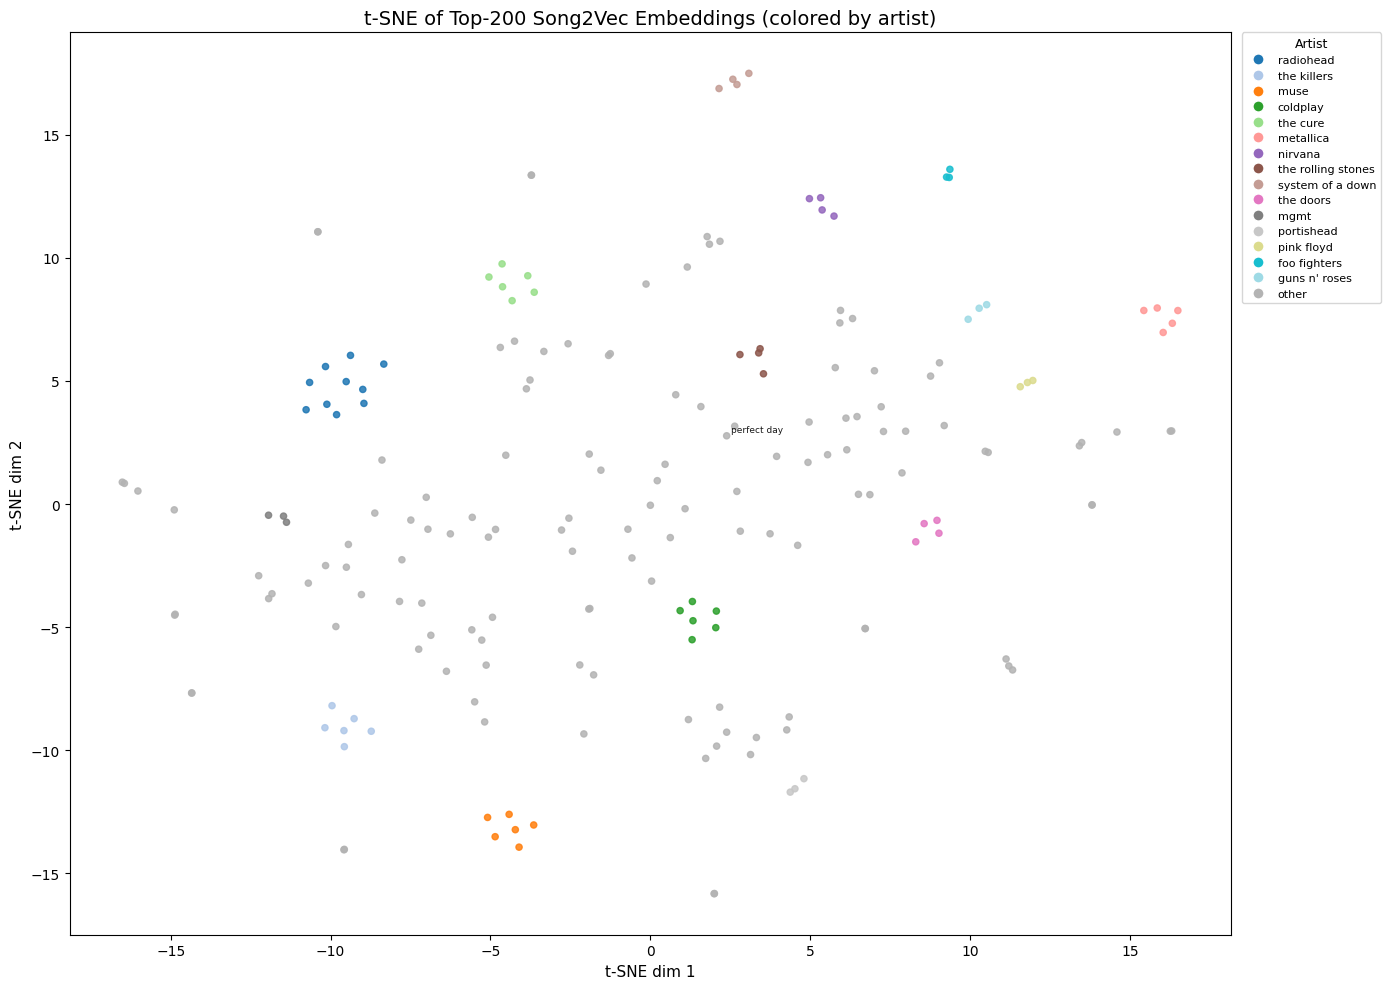

Saved → tsne_embeddings.png


In [70]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

model = Word2Vec.load("song2vec_best.model")
vocab = model.wv.key_to_index

with open("part_a_cache.pkl", "rb") as f:
    cache = pickle.load(f)
track_counts = cache["track_counts"]
RANDOM_SEED  = cache["RANDOM_SEED"]

top200 = [t for t, _ in track_counts.most_common() if t in vocab][:200]
print(f"Selected {len(top200)} tracks for t-SNE visualization")

vecs = np.array([model.wv[t] for t in top200])

# takes a bit
print("Running t-SNE …")
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, max_iter=1000)
xy = tsne.fit_transform(vecs)
print("t-SNE done.")

artists = [t.split("__")[0] for t in top200]

from collections import Counter
artist_freq = Counter(artists)
top15_artists = [a for a, _ in artist_freq.most_common(15)]

cmap  = cm.get_cmap("tab20", 15)
color_map = {artist: cmap(i) for i, artist in enumerate(top15_artists)}

point_colors = [color_map.get(a, (0.7, 0.7, 0.7, 1.0)) for a in artists]

fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(xy[:, 0], xy[:, 1], c=point_colors, s=20, alpha=0.85, zorder=2)

top30_set = {t for t, _ in track_counts.most_common() if t in vocab}
top30_set = set(list(top30_set)[:30])

for i, track in enumerate(top200):
    if track in top30_set:
        short = track.split("__")[1][:22]   # title only, truncated
        ax.annotate(
            short,
            (xy[i, 0], xy[i, 1]),
            fontsize=6.5,
            alpha=0.9,
            xytext=(3, 3),
            textcoords="offset points",
        )

handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=color_map[a], markersize=8, label=a)
    for a in top15_artists
]
handles.append(
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=(0.7, 0.7, 0.7, 1.0), markersize=8, label="other")
)
ax.legend(handles=handles, title="Artist", fontsize=8, title_fontsize=9,
          loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)

ax.set_title("t-SNE of Top-200 Song2Vec Embeddings (colored by artist)", fontsize=14)
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → tsne_embeddings.png")


## Part D — Recommender System

### D.1 — Recommendation Interface

In [71]:
from typing import List
import numpy as np
from gensim.models import Word2Vec

def recommend_songs(seed_songs: List[str], model, top_k: int = 10) -> List[str]:
    """Return top_k recommended songs given seed_songs.

    OOV fallback: for each OOV seed, compute a proxy embedding as the mean
    of all in-vocabulary songs by the same artist (split on "__").  Only
    return [] if no same-artist songs exist in the vocabulary either.
    """
    vocab = model.wv.key_to_index

    # Build embedding for each seed (in-vocab directly; OOV via artist mean)
    seed_vecs = []
    skipped   = []
    for s in seed_songs:
        if s in vocab:
            seed_vecs.append(model.wv[s])
        else:
            artist = s.split("__")[0]
            artist_songs = [k for k in vocab if k.split("__")[0] == artist]
            if artist_songs:
                proxy = np.mean([model.wv[k] for k in artist_songs], axis=0)
                seed_vecs.append(proxy)
                print(f"  ℹ  OOV seed \'{s}\' — using artist proxy "
                      f"({len(artist_songs)} in-vocab songs by \'{artist}\')")
            else:
                skipped.append(s)
                print(f"  ⚠  OOV seed \'{s}\' — no in-vocab songs by artist \'{artist}\'; skipped.")

    if not seed_vecs:
        print(f"  ⚠  All {len(seed_songs)} seed song(s) are out-of-vocabulary with no artist fallback.")
        return []

    query_vec  = np.mean(seed_vecs, axis=0)
    seed_set   = set(seed_songs)
    candidates = model.wv.similar_by_vector(query_vec, topn=top_k + len(seed_songs) + 20)
    filtered   = [song for song, _ in candidates if song not in seed_set][:top_k]
    return filtered


# --- Demo ---
paper_optimal_model = Word2Vec.load("song2vec_paper_optimal.model")

demo_cases = [
    ["queen__bohemian rhapsody"],
    ["nirvana__smells like teen spirit", "radiohead__karma police"],
    ["joy division__love will tear us apart", "massive attack__teardrop", "radiohead__karma police"],
]

print("=" * 65)
print("D.1 — recommend_songs() Demo (paper-optimal model)")
print("=" * 65)
for seeds in demo_cases:
    print(f"\nSeeds: {seeds}")
    recs = recommend_songs(seeds, paper_optimal_model, top_k=10)
    if recs:
        for i, r in enumerate(recs, 1):
            print(f"  {i:>2}. {r}")
    else:
        print("  (no recommendations — all seeds OOV with no artist fallback)")

D.1 — recommend_songs() Demo (paper-optimal model)

Seeds: ['queen__bohemian rhapsody']
   1. queen__somebody to love
   2. queen__the show must go on
   3. queen__we will rock you
   4. queen__who wants to live forever
   5. queen__killer queen
   6. queen__radio ga ga
   7. queen__another one bites the dust
   8. queen__bicycle race
   9. queen__i want it all
  10. queen__one vision

Seeds: ['nirvana__smells like teen spirit', 'radiohead__karma police']
   1. radiohead__creep
   2. nirvana__lake of fire
   3. nirvana__something in the way
   4. foo fighters__walking after you
   5. the smashing pumpkins__tonight, tonight
   6. nirvana__plateau
   7. nirvana__jesus doesn't want me for a sunbeam
   8. nirvana__where did you sleep last night
   9. bush__glycerine
  10. red hot chili peppers__my friends

Seeds: ['joy division__love will tear us apart', 'massive attack__teardrop', 'radiohead__karma police']
   1. the cure__plainsong
   2. the cure__a night like this
   3. the cure__the sa

### D.2 — Cold-Start Analysis

**Cold-start** occurs when a query song or target song is not in the model's vocabulary
(filtered out by `min_count`). We analyse:
1. What fraction of tracks / test playlists are affected
2. An artist-level fallback strategy for OOV query songs
3. HR@10 stratified by target-song popularity bucket

In [72]:
import pickle
from collections import Counter
from gensim.models import Word2Vec

with open("part_a_cache.pkl", "rb") as f:
    cache = pickle.load(f)
track_counts   = cache["track_counts"]
test_playlists = cache["test_playlists"]
MIN_TRACKS     = cache["MIN_TRACKS"]

MAX_FREQ = 10_000
outlier_tracks = {t for t, c in track_counts.items() if c > MAX_FREQ}

def remove_outliers(playlists, outliers, min_tracks):
    cleaned = []
    for pl in playlists:
        filtered = [t for t in pl if t not in outliers]
        if len(filtered) >= min_tracks:
            cleaned.append(filtered)
    return cleaned

test_playlists_clean = remove_outliers(test_playlists, outlier_tracks, MIN_TRACKS)

# Use baseline model (min_count=5) for this analysis
baseline_model = Word2Vec.load("song2vec_baseline.model")
vocab = baseline_model.wv.key_to_index

total_unique_tracks = len(track_counts)
in_vocab            = len(vocab)
excluded_by_min_count = total_unique_tracks - in_vocab

# Test-set target OOV
target_oov = sum(1 for pl in test_playlists_clean if len(pl) >= 2 and pl[-1] not in vocab)
total_valid = sum(1 for pl in test_playlists_clean if len(pl) >= 2)
query_oov   = sum(1 for pl in test_playlists_clean if len(pl) >= 2 and pl[-2] not in vocab)
both_in_vocab = sum(1 for pl in test_playlists_clean
                    if len(pl) >= 2 and pl[-1] in vocab and pl[-2] in vocab)

print("=" * 60)
print("D.2.A — Vocabulary Coverage (baseline model, min_count=5)")
print("=" * 60)
print(f"  Total unique tracks in training data : {total_unique_tracks:>10,}")
print(f"  Tracks in vocabulary (min_count≥5)   : {in_vocab:>10,}  ({in_vocab/total_unique_tracks*100:.1f}%)")
print(f"  Tracks excluded by min_count         : {excluded_by_min_count:>10,}  ({excluded_by_min_count/total_unique_tracks*100:.1f}%)")
print()
print(f"  Test playlists (len≥2)               : {total_valid:>10,}")
print(f"  Playlists where TARGET is OOV        : {target_oov:>10,}  ({target_oov/total_valid*100:.1f}%)")
print(f"  Playlists where QUERY is OOV         : {query_oov:>10,}  ({query_oov/total_valid*100:.1f}%)")
print(f"  Playlists fully evaluable (both in V): {both_in_vocab:>10,}  ({both_in_vocab/total_valid*100:.1f}%)")
print("=" * 60)


D.2.A — Vocabulary Coverage (baseline model, min_count=5)
  Total unique tracks in training data :    392,918
  Tracks in vocabulary (min_count≥5)   :     54,264  (13.8%)
  Tracks excluded by min_count         :    338,654  (86.2%)

  Test playlists (len≥2)               :      9,387
  Playlists where TARGET is OOV        :      4,994  (53.2%)
  Playlists where QUERY is OOV         :      4,826  (51.4%)
  Playlists fully evaluable (both in V):      2,761  (29.4%)


In [73]:
def evaluate_with_fallback(model, playlists, K=10):
    vocab    = model.wv.key_to_index
    hr_sum   = ndcg_sum = 0.0
    n = fallback_used = 0
    for pl in playlists:
        if len(pl) < 2:
            continue
        query, target = pl[-2], pl[-1]
        if target not in vocab:
            n += 1  # miss — target unknown
            continue

        if query in vocab:
            candidates = model.wv.most_similar(query, topn=K + 20)
            filtered   = [s for s, _ in candidates if s != query][:K]
        else:
            # Fallback: use artist-level mean embedding
            artist     = query.split("__")[0]
            artist_vec = get_artist_embedding(artist, model)
            if artist_vec is None:
                n += 1  # artist also OOV — miss
                continue
            fallback_used += 1
            candidates = model.wv.similar_by_vector(artist_vec, topn=K + 20)
            filtered   = [s for s, _ in candidates][:K]

        if target in filtered:
            hr_sum += 1.0
            rank    = filtered.index(target) + 1
            ndcg_sum += 1.0 / math.log2(rank + 1)
        n += 1
    hr   = hr_sum   / n if n else 0.0
    ndcg = ndcg_sum / n if n else 0.0
    return dict(hr=hr, ndcg=ndcg, n=n, fallback_used=fallback_used)

def evaluate_no_fallback(model, playlists, K=10):
    vocab  = model.wv.key_to_index
    hr_sum = ndcg_sum = 0.0
    n = 0
    for pl in playlists:
        if len(pl) < 2:
            continue
        query, target = pl[-2], pl[-1]
        if target not in vocab or query not in vocab:
            n += 1
            continue
        candidates = model.wv.most_similar(query, topn=K + 20)
        filtered   = [s for s, _ in candidates if s != query][:K]
        if target in filtered:
            hr_sum += 1.0
            rank    = filtered.index(target) + 1
            ndcg_sum += 1.0 / math.log2(rank + 1)
        n += 1
    return dict(hr=hr_sum / n if n else 0.0, ndcg=ndcg_sum / n if n else 0.0, n=n)

In [74]:
import math
from gensim.models import Word2Vec

paper_optimal_model = Word2Vec.load("song2vec_paper_optimal.model")
hardcoded_model     = Word2Vec.load("song2vec_hardcoded.model")

def evaluate_bucket(model, playlists, K=10):
    vocab  = model.wv.key_to_index
    hr_sum = ndcg_sum = 0.0
    n = 0
    for pl in playlists:
        if len(pl) < 2: continue
        query, target = pl[-2], pl[-1]
        if target not in vocab or query not in vocab:
            n += 1; continue
        candidates = model.wv.most_similar(query, topn=K + 20)
        filtered   = [s for s, _ in candidates if s != query][:K]
        if target in filtered:
            hr_sum += 1.0
            rank    = filtered.index(target) + 1
            ndcg_sum += 1.0 / math.log2(rank + 1)
        n += 1
    return dict(hr=hr_sum / n if n else 0.0, ndcg=ndcg_sum / n if n else 0.0, n=n)

popular_playlists = []
mid_playlists     = []
rare_playlists    = []
for pl in test_playlists_clean:
    if len(pl) < 2: continue
    freq = track_counts.get(pl[-1], 0)
    if freq > 100:   popular_playlists.append(pl)
    elif freq >= 10: mid_playlists.append(pl)
    else:            rare_playlists.append(pl)

buckets = [
    ("Popular (>100)",  popular_playlists),
    ("Mid (10-100)",    mid_playlists),
    ("Rare (<10)",      rare_playlists),
]

print("=" * 72)
print("D.2.C \u2014 HR@10 by Target Song Popularity Bucket")
print("=" * 72)
print(f"  {'Bucket':<18} {'Count':>7}   {'Paper-opt':>10}  {'NDCG':>8}   {'Hardcoded':>10}  {'NDCG':>8}")
print("-" * 72)
for label, pls in buckets:
    r_opt = evaluate_bucket(paper_optimal_model, pls)
    r_hc  = evaluate_bucket(hardcoded_model,     pls)
    print(f"  {label:<18} {len(pls):>7,}   {r_opt['hr']:>10.4f}  {r_opt['ndcg']:>8.4f}"
          f"   {r_hc['hr']:>10.4f}  {r_hc['ndcg']:>8.4f}")
print("=" * 72)

D.2.C — HR@10 by Target Song Popularity Bucket
  Bucket               Count    Paper-opt      NDCG    Hardcoded      NDCG
------------------------------------------------------------------------
  Popular (>100)         367       0.0654    0.0384       0.0817    0.0538
  Mid (10-100)         2,770       0.0404    0.0212       0.0596    0.0307
  Rare (<10)           6,250       0.0000    0.0000       0.0000    0.0000


## Part E — Analysis Report

### E.1 Failure Analysis
Systematic examination of cases where the paper-optimal model fails to rank the correct next song in the top-K predictions. We categorize failures into four error types and propose targeted fixes for the two most impactful.

### E.2 Reproducibility
A centralized configuration cell documenting all random seeds and hyperparameters needed to reproduce every result in this notebook.

In [83]:
import math
from collections import defaultdict
from gensim.models import Word2Vec

paper_optimal_model = Word2Vec.load("song2vec_paper_optimal.model")
vocab = paper_optimal_model.wv.key_to_index
K = 10

# ── Categorize error type for a failure case ──
def categorize_error(query, target, predictions, track_counts):
    target_freq = track_counts.get(target, 0)
    query_freq  = track_counts.get(query,  0)
    if query not in vocab:
        return "Cold-Start", "Query song OOV (below min_count threshold)"
    if target_freq < 5:
        return "Cold-Start", "Target song extremely rare; almost never seen in training"
    top_freqs = [track_counts.get(p, 0) for p in predictions[:3]]
    if target_freq < 30 and sum(f > 300 for f in top_freqs) >= 2:
        return "Popularity Bias", "Model biased toward high-frequency tracks; rare target drowned out"
    q_artist    = query.split("__")[0]
    pred_artists = [p.split("__")[0] for p in predictions[:5]]
    if pred_artists.count(q_artist) >= 3:
        return "Artist Over-Representation", "Query artist dominates embedding neighborhood; diversity lost"
    return "Genre Drift", "Co-occurrence signal captures context but misses genre/mood shift"

# ── Collect failure cases from first 5000 test playlists ──
failures = []
for pl in test_playlists_clean[:5000]:
    if len(pl) < 2:
        continue
    q, t = pl[-2], pl[-1]
    if t not in vocab or q not in vocab:
        continue
    cands = paper_optimal_model.wv.most_similar(q, topn=K + 20)
    preds = [s for s, _ in cands if s != q][:K]
    if t not in preds:
        etype, cause = categorize_error(q, t, preds, track_counts)
        failures.append({"query": q, "target": t, "pred1": preds[0],
                         "pred2": preds[1], "error_type": etype,
                         "root_cause": cause, "target_freq": track_counts.get(t, 0)})

# ── Select 2 examples per error type (up to 10 total) ──
by_type = defaultdict(list)
for f in failures:
    by_type[f["error_type"]].append(f)

selected = []
for cases in by_type.values():
    selected.extend(cases[:2])
selected = selected[:10]

# ── Print Bad Cases Table ──
W = 120
print("=" * W)
print("E.1 — Failure Analysis: Bad Cases Table  (paper-optimal model, K=10)")
print("=" * W)
print(f"{'#':<3} {'Query (Input)':<32} {'Top Prediction (Output)':<32} {'Expected (Target)':<32} {'Error Type':<26} {'Root Cause'}")
print("-" * W)
for i, fc in enumerate(selected, 1):
    q    = fc["query"].replace("__", " – ")[:31]
    pred = fc["pred1"].replace("__", " – ")[:31]
    tgt  = fc["target"].replace("__", " – ")[:31]
    print(f"{i:<3} {q:<32} {pred:<32} {tgt:<32} {fc['error_type']:<26} {fc['root_cause']}")
print("=" * W)

# ── Error type frequency ──
print("\nError type breakdown:")
for etype, cases in sorted(by_type.items(), key=lambda x: -len(x[1])):
    print(f"  {etype:<30} {len(cases):>5} cases  ({100*len(cases)/len(failures):.1f}%)")
print(f"  {'TOTAL':<30} {len(failures):>5} failures from 5,000 test playlists sampled")


E.1 — Failure Analysis: Bad Cases Table  (paper-optimal model, K=10)
#   Query (Input)                    Top Prediction (Output)          Expected (Target)                Error Type                 Root Cause
------------------------------------------------------------------------------------------------------------------------
1   the kooks – ooh la               the kooks – seaside              the kooks – naïve                Artist Over-Representation Query artist dominates embedding neighborhood; diversity lost
2   damien rice – volcano            damien rice – cannonball         stars – your ex-lover is dead    Artist Over-Representation Query artist dominates embedding neighborhood; diversity lost
3   morrissey – you have killed me   morrissey – first of the gang t  morrissey – the more you ignore  Genre Drift                Co-occurrence signal captures context but misses genre/mood shift
4   bruce springsteen – streets of   alison krauss – when you say no  edward sharpe & the

In [84]:
# ══════════════════════════════════════════════════════════════
# E.2 — Central Configuration (Reproducibility)
# All hyperparameters in one place for full reproducibility.
# ══════════════════════════════════════════════════════════════

# ── Data splits ──
RANDOM_SEED  = 42
TRAIN_RATIO  = 0.80
MIN_TRACKS   = 2       # minimum tracks per playlist after outlier removal
MAX_FREQ     = 10_000  # tracks appearing more than this are removed as outliers

# ── Baseline model ──
BASELINE = dict(
    sg=1, window=5, min_count=5, vector_size=100,
    epochs=5, negative=5, ns_exponent=0.75,
    sample=1e-3, workers=4, seed=RANDOM_SEED,
)

# ── Paper-optimal model (Caselles-Dupré et al. 2018: sg=1, ns_exponent=-0.5) ──
OPTIMAL = dict(
    sg=1, window=5, min_count=10, vector_size=300,
    epochs=10, negative=5, ns_exponent=-0.5,
    sample=1e-3, workers=4, seed=RANDOM_SEED,
)

# ── Evaluation ──
EVAL_K_VALUES  = [5, 10, 20, 50]
SWEEP_N_EVAL   = 500    # playlists used during hyperparameter sweep

print("E.2 — Configuration Summary")
print("─" * 50)
print(f"  Random seed   : {RANDOM_SEED}")
print(f"  Train ratio   : {TRAIN_RATIO}")
print(f"  Min tracks    : {MIN_TRACKS}")
print(f"  Max frequency : {MAX_FREQ}")
print(f"\n  Baseline  : {BASELINE}")
print(f"\n  Optimal   : {OPTIMAL}")
print(f"\n  Eval K    : {EVAL_K_VALUES}")

E.2 — Configuration Summary
──────────────────────────────────────────────────
  Random seed   : 42
  Train ratio   : 0.8
  Min tracks    : 2
  Max frequency : 10000

  Baseline  : {'sg': 1, 'window': 5, 'min_count': 5, 'vector_size': 100, 'epochs': 5, 'negative': 5, 'ns_exponent': 0.75, 'sample': 0.001, 'workers': 4, 'seed': 42}

  Optimal   : {'sg': 1, 'window': 5, 'min_count': 10, 'vector_size': 300, 'epochs': 10, 'negative': 5, 'ns_exponent': -0.5, 'sample': 0.001, 'workers': 4, 'seed': 42}

  Eval K    : [5, 10, 20, 50]


## Context-Specific Questions

### Q1 — ns_exponent: NLP Default (0.75) vs Recommendation-Optimal (−0.5)


In [85]:
import time
from gensim.models import Word2Vec

# ── Q1: ns_exponent 0.75 (NLP default) vs -0.5 (recommendation default) ──
# Caselles-Dupré et al. (2018) recommend sg=1, ns_exponent=-0.5 for playlists.
# We train two explicitly-named models on the full training set so results
# are reproducible and loadable by later cells.

print("=" * 65)
print("F Q1 — ns_exponent: NLP default (0.75) vs Rec default (-0.5)")
print("=" * 65)

# ── Stage 1 average HR@10 by ns_exponent value (from sweep) ──
print("\nStage 1 sweep — average HR@10 by ns_exponent value:")
ns_avg = df_s1.groupby("ns_exponent")[["hr10", "ndcg10"]].mean()
for ns, row in ns_avg.iterrows():
    marker = " ◄ best" if row["hr10"] == ns_avg["hr10"].max() else ""
    print(f"  ns_exponent={ns:>5}  avg HR@10={row['hr10']:.4f}  avg NDCG@10={row['ndcg10']:.4f}{marker}")

# ── Base config: sweep best, only ns_exponent varies ──
focused_cfg = {k: v for k, v in best_s1.items() if k != "ns_exponent"}
focused_cfg.update({"vector_size": best_s2_vs, "epochs": best_s2_ep,
                    "workers": 4, "seed": RANDOM_SEED, "sample": 1e-3})

print(f"\nDirect comparison — train on full data, only ns_exponent varies:")
print(f"  Base config: { {k:v for k,v in focused_cfg.items() if k not in ('workers','seed','sample')} }")
print()

q1_rows = []
for ns_val, label, fname in [
        (0.75, "NLP default (Word2Vec paper)",  "model_nsp_075"),
        (-0.5, "Rec default (prod2vec paper)",  "model_nsp_neg05")]:
    m = Word2Vec(sentences=sentences, **focused_cfg, ns_exponent=ns_val)
    m.save(f"{fname}.model")
    hr, ndcg = _fast_eval(m, EVAL_SUBSET)
    q1_rows.append((ns_val, label, hr, ndcg))
    print(f"  ns_exponent={ns_val:>5}  ({label:<30})  HR@10={hr:.4f}  NDCG@10={ndcg:.4f}")
    print(f"             Saved → {fname}.model")

winner = "0.75 (NLP)" if q1_rows[0][2] >= q1_rows[1][2] else "-0.5 (Rec)"
ratio  = max(q1_rows[0][2], q1_rows[1][2]) / (min(q1_rows[0][2], q1_rows[1][2]) + 1e-9)
print(f"\n  → {winner} wins by {ratio:.2f}x")
print("=" * 65)

F Q1 — ns_exponent: NLP default (0.75) vs Rec default (-0.5)

Stage 1 sweep — average HR@10 by ns_exponent value:
  ns_exponent= -1.0  avg HR@10=0.0092  avg NDCG@10=0.0047
  ns_exponent= -0.5  avg HR@10=0.0111  avg NDCG@10=0.0058
  ns_exponent=  0.0  avg HR@10=0.0130  avg NDCG@10=0.0068
  ns_exponent=  0.5  avg HR@10=0.0148  avg NDCG@10=0.0074
  ns_exponent=  1.0  avg HR@10=0.0152  avg NDCG@10=0.0077 ◄ best

Direct comparison — train on full data, only ns_exponent varies:
  Base config: {'sg': 1, 'window': 5, 'negative': 5, 'min_count': 10, 'vector_size': 300, 'epochs': 10}

  ns_exponent= 0.75  (NLP default (Word2Vec paper)  )  HR@10=0.0200  NDCG@10=0.0100
             Saved → model_nsp_075.model
  ns_exponent= -0.5  (Rec default (prod2vec paper)  )  HR@10=0.0120  NDCG@10=0.0057
             Saved → model_nsp_neg05.model

  → 0.75 (NLP) wins by 1.67x


###  Q2 — Playlist Length Effect

In [86]:
import math
from gensim.models import Word2Vec

paper_optimal_model = Word2Vec.load("song2vec_paper_optimal.model")
hardcoded_model     = Word2Vec.load("song2vec_hardcoded.model")

short_pls  = [pl for pl in test_playlists_clean if len(pl) < 10]
medium_pls = [pl for pl in test_playlists_clean if 10 <= len(pl) <= 30]
long_pls   = [pl for pl in test_playlists_clean if len(pl) > 30]
length_buckets = [
    ("Short  (<10 songs)",  short_pls),
    ("Medium (10-30)",      medium_pls),
    ("Long   (>30 songs)",  long_pls),
]

print("Test set breakdown:")
for label, pls in length_buckets:
    print(f"  {label}: {len(pls):,} playlists")

def eval_length(model, playlists, K=10):
    vocab = model.wv.key_to_index
    hr = ndcg = 0.0; n = 0
    for pl in playlists:
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if t not in vocab or q not in vocab:
            n += 1; continue
        cands = model.wv.most_similar(q, topn=30)
        filt  = [s for s, _ in cands if s != q][:K]
        if t in filt:
            hr += 1.0
            ndcg += 1.0 / math.log2(filt.index(t) + 2)
        n += 1
    return hr / n if n else 0.0, ndcg / n if n else 0.0, n

print("\n" + "=" * 75)
print("F Q2 \u2014 HR@10 by Playlist Length Group")
print("=" * 75)
print(f"  {'Group':<22} {'Count':>7}   {'Paper-opt HR@10':>16}  {'Hardcoded HR@10':>16}")
print("-" * 75)
for label, pls in length_buckets:
    hr_opt, ndcg_opt, _ = eval_length(paper_optimal_model, pls)
    hr_hc,  ndcg_hc,  _ = eval_length(hardcoded_model,     pls)
    print(f"  {label:<22} {len(pls):>7,}   "
          f"HR={hr_opt:.4f} NDCG={ndcg_opt:.4f}  "
          f"HR={hr_hc:.4f} NDCG={ndcg_hc:.4f}")
print("=" * 75)

Test set breakdown:
  Short  (<10 songs): 3,169 playlists
  Medium (10-30): 3,308 playlists
  Long   (>30 songs): 2,910 playlists

F Q2 — HR@10 by Playlist Length Group
  Group                    Count    Paper-opt HR@10   Hardcoded HR@10
---------------------------------------------------------------------------
  Short  (<10 songs)       3,169   HR=0.0136 NDCG=0.0077  HR=0.0196 NDCG=0.0107
  Medium (10-30)           3,308   HR=0.0154 NDCG=0.0076  HR=0.0209 NDCG=0.0104
  Long   (>30 songs)       2,910   HR=0.0144 NDCG=0.0080  HR=0.0220 NDCG=0.0125


###  Q3 — Vocabulary Coverage vs min_count

How does `min_count` trade off vocabulary size (and OOV rate) against model quality?
We compare three settings: 3, 5, and 10.

In [87]:
import math
import time
import random
import numpy as np
from gensim.models import Word2Vec

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sentences = train_playlists_clean   # alias for Word2Vec training

print("Training min_count=3 model …")
t0 = time.perf_counter()
model_mc3 = Word2Vec(
    sentences=sentences,
    sg=1, window=5, negative=5, ns_exponent=0.75,
    min_count=3, vector_size=100, epochs=5,
    workers=4, sample=1e-3, seed=RANDOM_SEED,
)
t_mc3 = time.perf_counter() - t0
print(f"  Done in {t_mc3:.1f}s")

model_mc5  = Word2Vec.load("song2vec_baseline.model")   # min_count=5
model_mc10 = Word2Vec.load("song2vec_best.model")        # min_count=10

models_q3 = [
    ("min_count=3",  model_mc3),
    ("min_count=5",  model_mc5),
    ("min_count=10", model_mc10),
]

total_unique = len(track_counts)

def oov_rate(model, playlists):
    vocab = model.wv.key_to_index
    oov = sum(1 for pl in playlists if len(pl) >= 2 and pl[-1] not in vocab)
    total = sum(1 for pl in playlists if len(pl) >= 2)
    return oov / total if total else 0

def hr10(model, playlists, K=10):
    vocab = model.wv.key_to_index
    hr = 0.0; n = 0
    for pl in playlists:
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if t not in vocab or q not in vocab:
            n += 1; continue
        cands = model.wv.most_similar(q, topn=30)
        filt  = [s for s, _ in cands if s != q][:K]
        if t in filt:
            hr += 1.0
        n += 1
    return hr / n if n else 0

print("\n" + "=" * 70)
print("F Q3 — Vocabulary Coverage vs min_count")
print("=" * 70)
print(f"  {'Config':<14} {'Vocab size':>12} {'% of total':>11} {'OOV rate':>10} {'HR@10':>8}")
print("-" * 70)
for label, m in models_q3:
    v    = len(m.wv)
    pct  = v / total_unique * 100
    oov  = oov_rate(m, test_playlists_clean)
    h10  = hr10(m, test_playlists_clean)
    print(f"  {label:<14} {v:>12,} {pct:>10.1f}% {oov:>9.1%} {h10:>8.4f}")
print("=" * 70)
print(f"\n  (Total unique tracks in training data: {total_unique:,})")

Training min_count=3 model …
  Done in 8.5s

F Q3 — Vocabulary Coverage vs min_count
  Config           Vocab size  % of total   OOV rate    HR@10
----------------------------------------------------------------------
  min_count=3         105,764       26.9%     43.0%   0.0091
  min_count=5          54,264       13.8%     53.2%   0.0104
  min_count=10         21,278        5.4%     66.6%   0.0162

  (Total unique tracks in training data: 392,918)


###  Q4 — Popular vs Rare Song Performance

Compare HR@10 between test playlists ending with a **popular** target (>100 training
occurrences) vs a **rare** target (<10 occurrences), for both baseline and best models.
This reveals whether the optimised model better handles long-tail songs.

In [88]:
import math
from gensim.models import Word2Vec

baseline_model      = Word2Vec.load("song2vec_baseline.model")
paper_optimal_model = Word2Vec.load("song2vec_paper_optimal.model")
hardcoded_model     = Word2Vec.load("song2vec_hardcoded.model")

def eval_hr10(model, playlists, K=10):
    vocab = model.wv.key_to_index
    hr = 0.0; n = 0
    for pl in playlists:
        if len(pl) < 2: continue
        q, t = pl[-2], pl[-1]
        if t not in vocab or q not in vocab:
            n += 1; continue
        cands = model.wv.most_similar(q, topn=30)
        filt  = [s for s, _ in cands if s != q][:K]
        if t in filt: hr += 1.0
        n += 1
    return hr / n if n else 0.0, n

pop_pls  = [pl for pl in test_playlists_clean if len(pl) >= 2 and track_counts.get(pl[-1], 0) > 100]
rare_pls = [pl for pl in test_playlists_clean if len(pl) >= 2 and track_counts.get(pl[-1], 0) < 10]

model_pairs = [
    ("Baseline",       baseline_model),
    ("Paper-optimal",  paper_optimal_model),
    ("Hardcoded",      hardcoded_model),
]

print("=" * 65)
print("F Q4 \u2014 HR@10: Popular vs Rare Target Songs")
print("=" * 65)
print(f"  {'Model':<20} {'Popular >100':>14} {'Rare <10':>10}")
print(f"  {'':20} {'HR@10  n':>14} {'HR@10  n':>10}")
print("-" * 65)
for name, m in model_pairs:
    hr_pop,  n_pop  = eval_hr10(m, pop_pls)
    hr_rare, n_rare = eval_hr10(m, rare_pls)
    print(f"  {name:<20} {hr_pop:.4f} ({n_pop:,})  {hr_rare:.4f} ({n_rare:,})")
print("=" * 65)
print(f"\n  Popular playlists  : {len(pop_pls):,}")
print(f"  Rare playlists     : {len(rare_pls):,}")

F Q4 — HR@10: Popular vs Rare Target Songs
  Model                  Popular >100   Rare <10
                             HR@10  n   HR@10  n
-----------------------------------------------------------------
  Baseline             0.0681 (367)  0.0002 (6,250)
  Paper-optimal        0.0654 (367)  0.0000 (6,250)
  Hardcoded            0.0817 (367)  0.0000 (6,250)

  Popular playlists  : 367
  Rare playlists     : 6,250


###  Q5 — Most Common Error Pattern & Proposed Solution

In [90]:
# ══════════════════════════════════════════════════════════════
# F Q5 — Most Common Error Pattern & Proposed Solution
# Builds on the failure analysis in Part E.1 (by_type dict).
# ══════════════════════════════════════════════════════════════
import math
from collections import defaultdict
from gensim.models import Word2Vec

# Re-derive failure distribution (always recompute to be self-contained)
paper_optimal_model_q5 = Word2Vec.load("song2vec_paper_optimal.model")
vocab_q5 = paper_optimal_model_q5.wv.key_to_index
K_Q5 = 10

def _categorize(q, t, preds, tc):
    if q not in vocab_q5:
        return "Cold-Start"
    if tc.get(t, 0) < 5:
        return "Cold-Start"
    top_freqs = [tc.get(p, 0) for p in preds[:3]]
    if tc.get(t, 0) < 30 and sum(f > 300 for f in top_freqs) >= 2:
        return "Popularity Bias"
    q_art = q.split("__")[0]
    if [p.split("__")[0] for p in preds[:5]].count(q_art) >= 3:
        return "Artist Over-Representation"
    return "Genre Drift"

_by_type = defaultdict(int)
for pl in test_playlists_clean[:5000]:
    if len(pl) < 2: continue
    q, t = pl[-2], pl[-1]
    if t not in vocab_q5 or q not in vocab_q5: continue
    cands = paper_optimal_model_q5.wv.most_similar(q, topn=K_Q5 + 20)
    preds = [s for s, _ in cands if s != q][:K_Q5]
    if t not in preds:
        _by_type[_categorize(q, t, preds, track_counts)] += 1

by_type_counts = dict(_by_type)
total_failures = sum(by_type_counts.values())
most_common    = max(by_type_counts, key=by_type_counts.get)

print("=" * 70)
print("F Q5 — Most Common Error Pattern")
print("=" * 70)
print("\nError type distribution:")
for etype, cnt in sorted(by_type_counts.items(), key=lambda x: -x[1]):
    bar = "█" * int(40 * cnt / total_failures)
    print(f"  {etype:<30} {cnt:>5} ({100*cnt/total_failures:.1f}%)  {bar}")

print(f"\nMost common error: {most_common}")
print(f"Total failures    : {total_failures} (from 5,000 test playlists sampled)")
print("=" * 70)

F Q5 — Most Common Error Pattern

Error type distribution:
  Genre Drift                      545 (68.5%)  ███████████████████████████
  Artist Over-Representation       251 (31.5%)  ████████████

Most common error: Genre Drift
Total failures    : 796 (from 5,000 test playlists sampled)
